# Data-driven ad strategy for electric vehicle charging stations

## Optimizing advertising placement based on user charging patterns

Dataset: https://www.kaggle.com/datasets/valakhorasani/electric-vehicle-charging-patterns

---

## 1. Introduction

## Business Problem

Electric vehicle charging stations are strategic points where users spend time during the recharging process. This makes them ideal locations for displaying personalized and relevant advertisements. The challenge is to optimize the advertising strategy by identifying user behavior patterns to determine the best moments and types of ads.

This project aims to segment users based on their charging time and behaviors to maximize the impact of advertising campaigns.

## Hypothesis

The main hypothesis is that charging patterns vary according to user type and vehicle characteristics, making it possible to identify optimal moments for different types of ads.

### Specific Hypotheses:
- **Users with longer charging times**: Typically long-distance drivers who tend to charge during nighttime hours. They would be more receptive to ads for hotels or restaurants.
- **Users with shorter charging times**: Typically urban drivers who charge during the day. They would be more receptive to ads for coffee shops or quick services.

---

## Methodology: CRISP-DM

The project follows the CRISP-DM (Cross-Industry Standard Process for Data Mining) methodology, a standard framework for data science projects that includes the following six phases:

### 1. Business Understanding
- **General Objective**: Develop an analysis and prediction system to maximize advertising impact at charging stations.
- **Specific Objectives**:  
  - Design a predictive model to identify optimal moments for advertising.  
  - Establish a scalable system capable of incorporating new variables in the future.

### 2. Data Understanding
- Dataset from Kaggle with 1,320 charging session records
- Exploratory Data Analysis (EDA) to identify patterns and validate hypotheses
- Focus on variables relevant to advertising optimization

### 3. Data Preparation
- Physics-based data cleaning to ensure consistency
- Variable selection based on business objectives
- Feature engineering for clustering analysis

### 4. Modeling
- K-Means clustering to segment users based on charging behavior
- Two clusters identified: Long-distance travelers vs Urban/suburban users

### 5. Evaluation
- Silhouette analysis to assess cluster quality
- Validation of clusters against business hypotheses

### 6. Deployment (Out of Scope)
- As an academic project, actual deployment is not included
- However, recommendations for advertising strategies are provided
- Foundation laid for future implementation

---

## 2. Data Understanding

### Objective: Optimize Advertisement Placement at EV Charging Stations

This analysis identifies user behavior patterns to develop targeted advertising strategies. The approach follows a two-tier methodology:

1. **Primary Analysis**: Core dataset exploration using available features
2. **Enhanced Analysis**: Feature engineering and derived insights

### 2a. Selected Variables for Ad Strategy

The following variables were chosen for their specific contributions to understanding ad placement opportunities:

- `UserType`: Identifies commuter vs traveler personas for targeted content
- `Battery.Capacity.kWh`: Proxy for vehicle type and economic segment
- `DayOfWeek`: Captures business vs leisure travel patterns
- `Charging.Start.Time`: Determines peak usage hours for ad scheduling
- `Charging.End.Time`: Helps calculate total session duration
- `Charging.Duration.Hours`: Defines the ad exposure window
- `ChargerType`: Indicates charging speed and wait time
- `Energy.Consumed.kWh`: Proxy for trip distance (local vs long-distance)
- `Charging.Station.Location`: Enables geographic-specific campaigns
- `State.of.Charge.Start.%`: Reveals user urgency level (emergency vs planned)
- `State.of.Charge.End.%`: Shows charging completion patterns
- `Temperature`: Affects battery efficiency and enables weather-based ad content (hot/cold beverage ads, climate services)

This variable selection enables data-driven decisions for ad placement timing, content customization, and audience targeting while maintaining analytical robustness despite potential data gaps.

Loading data from Kaggle: ev_charging_patterns.csv 
Dataset dimensions: 1320 rows x 20 columns


╔════════════════════════════════════════════════════╗
║     COMPREHENSIVE EV CHARGING DATA ANALYSIS        ║
║         FOR AD STRATEGY OPTIMIZATION               ║
╚════════════════════════════════════════════════════════╝


Dataset: ev_charging_patterns.csv 
Dimensions: 1,320 rows x 20 columns
Date range: 2024-01-01 to 2024-02-24 23:00:00 


Column Types Summary
───────────────────── 


Data.Type    Count   Percentage
----------  ------  -----------
numeric         10        50.0%
character        8        40.0%
POSIXct          2        10.0%


Duplicate records check:
────────────────────────────── 
Total duplicate rows: 0 (0.00%) 
✓ No duplicate records found

=== BRIEF STATISTICS BEFORE THE IMPOSSIBLE-VALUE FILTER ===
══════════════════════════════════════════════════ 


variable                                   n   missing     mean   median      sd      min      max    q25      q75


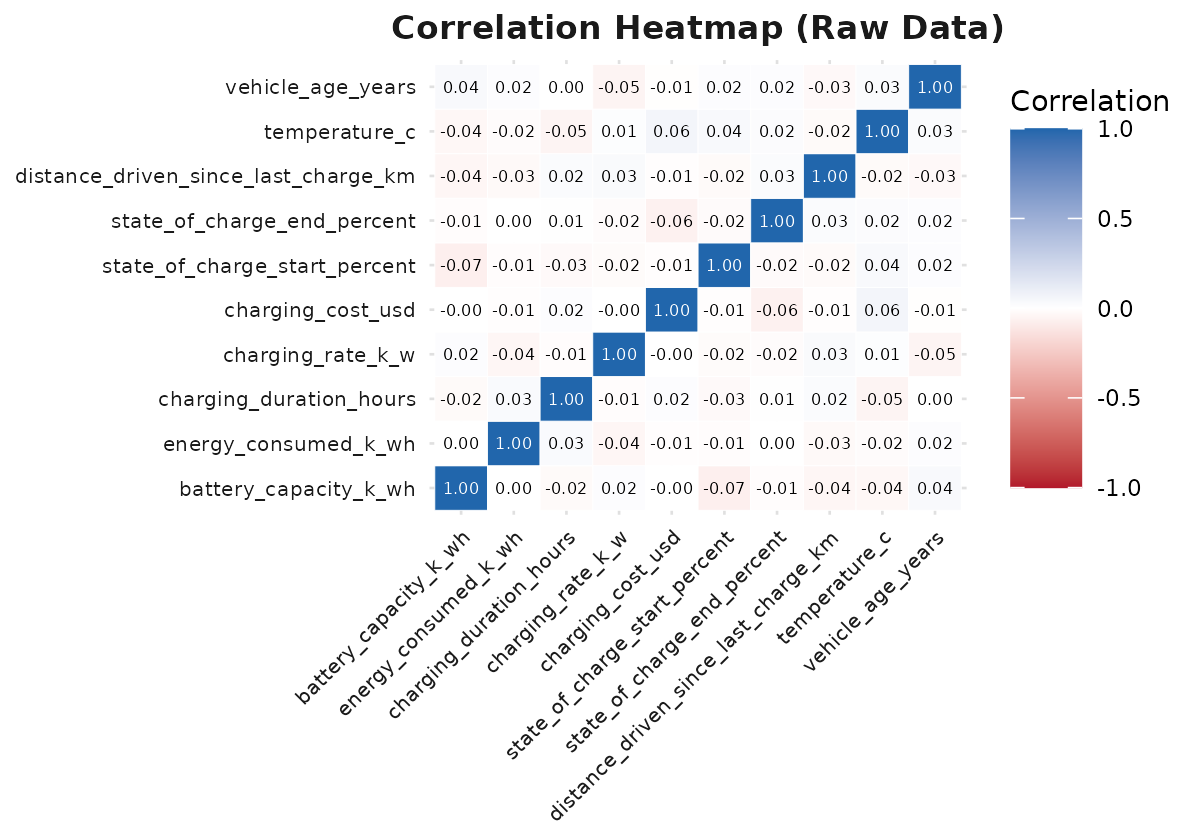

✓ Correlation heatmap (raw data) rendered inline

=== DATA CLEANING: REMOVING IMPOSSIBLE VALUES ===
══════════════════════════════════════════════════ 

Validation rules applied (grounded in domain knowledge):
──────────────────────────────────────── 
• [SOC_RANGE_HIGH]
    SOC must not exceed 100%
    Condition: state_of_charge_end_percent > 100

• [SOC_RANGE_LOW]
    SOC must not fall below 0%
    Condition: state_of_charge_start_percent < 0

• [SOC_MONOTONIC]
    SOC should increase during charging (±4% tolerance)
    Condition: state_of_charge_start_percent > state_of_charge_end_percent + soc_noise_tolerance_pct

• [SOC_ENERGY_GAP]
    SOC delta vs delivered energy gap >40% (warning raised above 30%)
    Condition: discrepancy_pct > energy_soc_invalid_pct

• [BATTERY_POSITIVE]
    Battery capacity must be positive
    Condition: battery_capacity_k_wh <= 0

• [ENERGY_POSITIVE]
    Energy consumed must be positive
    Condition: energy_consumed_k_wh <= 0

• [TIME_ORDER]
    Start tim

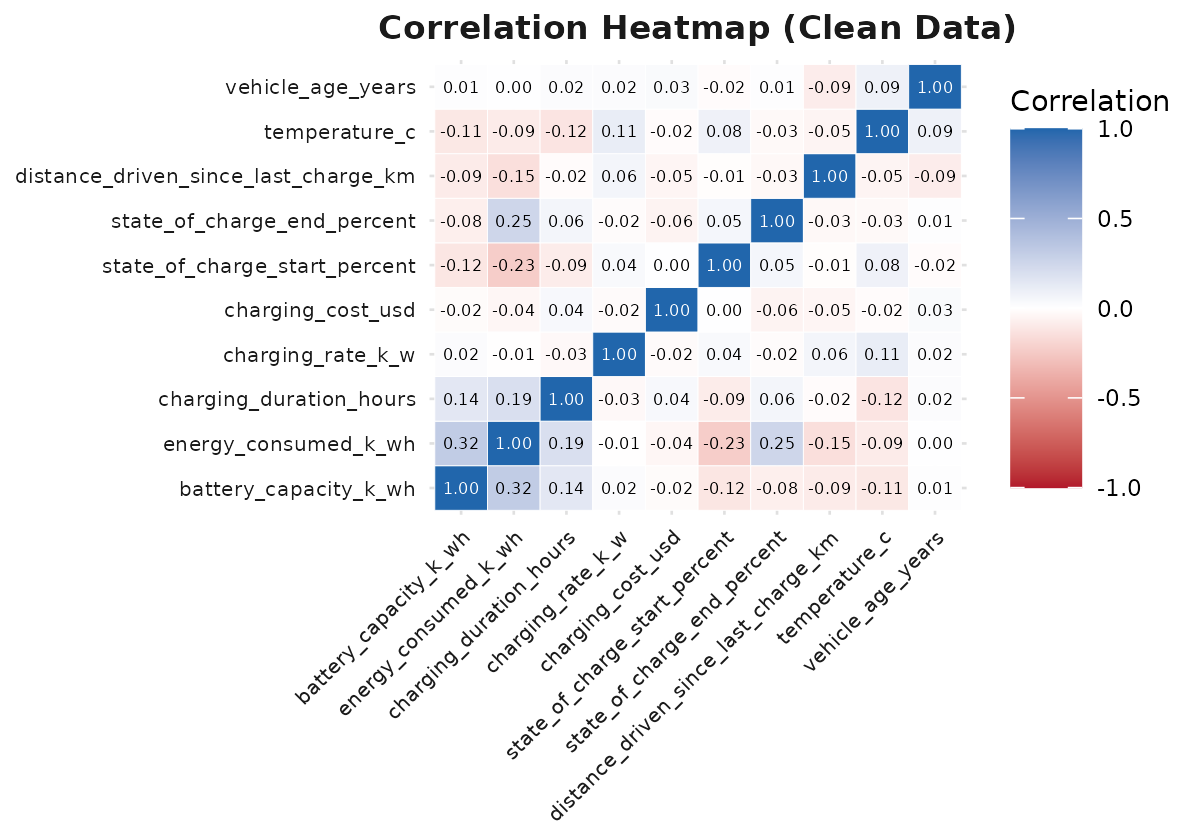

✓ Correlation heatmap (clean data) rendered inline

=== TARGETED UNIVARIATE ANALYSIS ===
══════════════════════════════════════════════════ 

User Type Distribution
--------------------------- 


 


Value                     Count   Percentage (%)
-----------------------  ------  ---------------
Commuter                    143             38.4
Casual Driver               123             33.1
Long-Distance Traveler      106             28.5



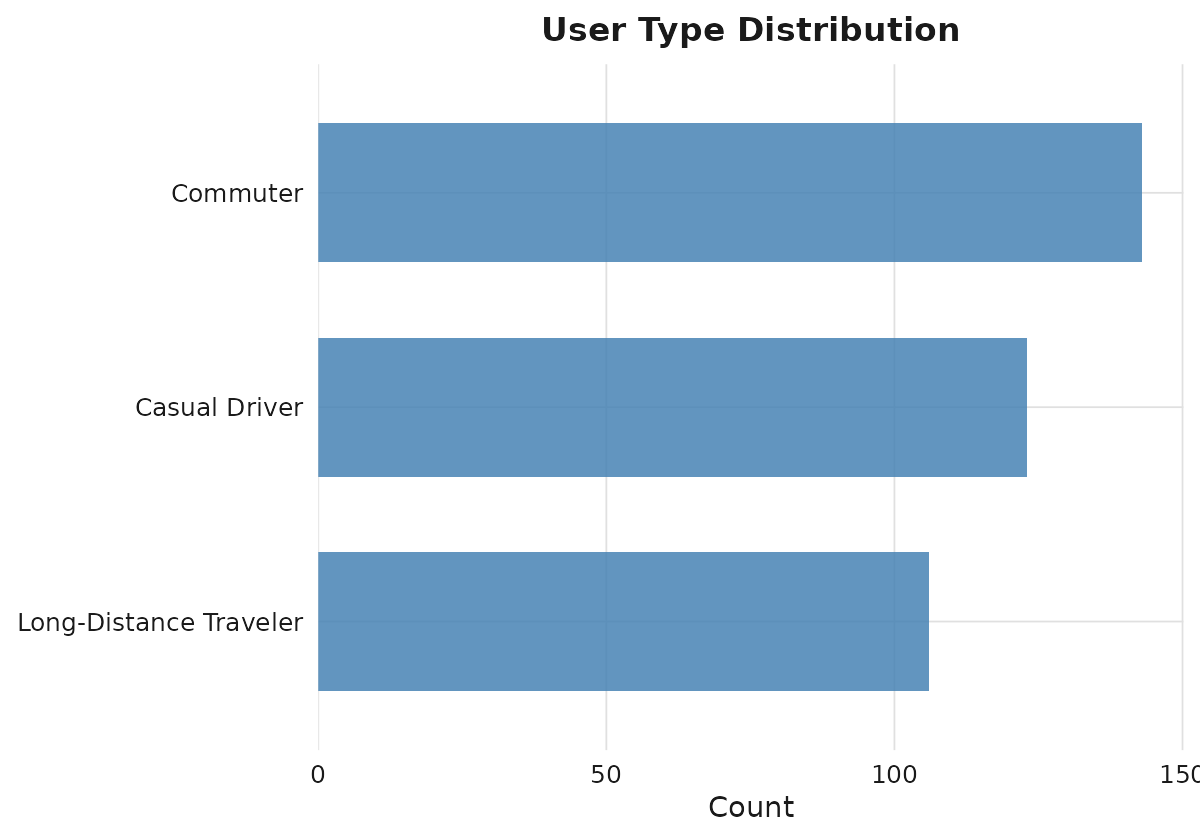


Day of Week Distribution
----------------------------- 


 


Value        Count   Percentage (%)
----------  ------  ---------------
Monday          65             17.5
Sunday          57             15.3
Saturday        54             14.5
Friday          53             14.2
Wednesday       52             14.0
Tuesday         51             13.7
Thursday        40             10.8



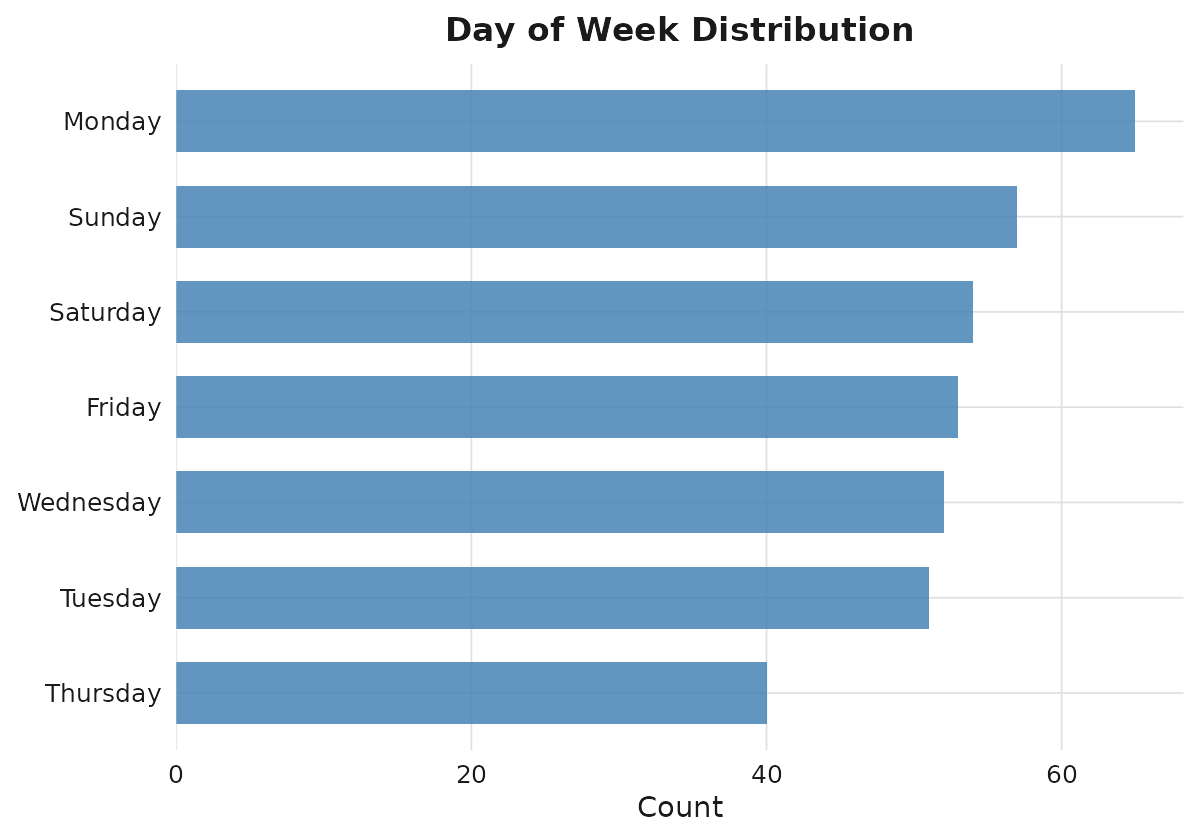


Charging Station Location Distribution
------------------------------------------- 


 


Value            Count   Percentage (%)
--------------  ------  ---------------
San Francisco       81             21.8
Los Angeles         76             20.4
Houston             75             20.2
New York            71             19.1
Chicago             69             18.6



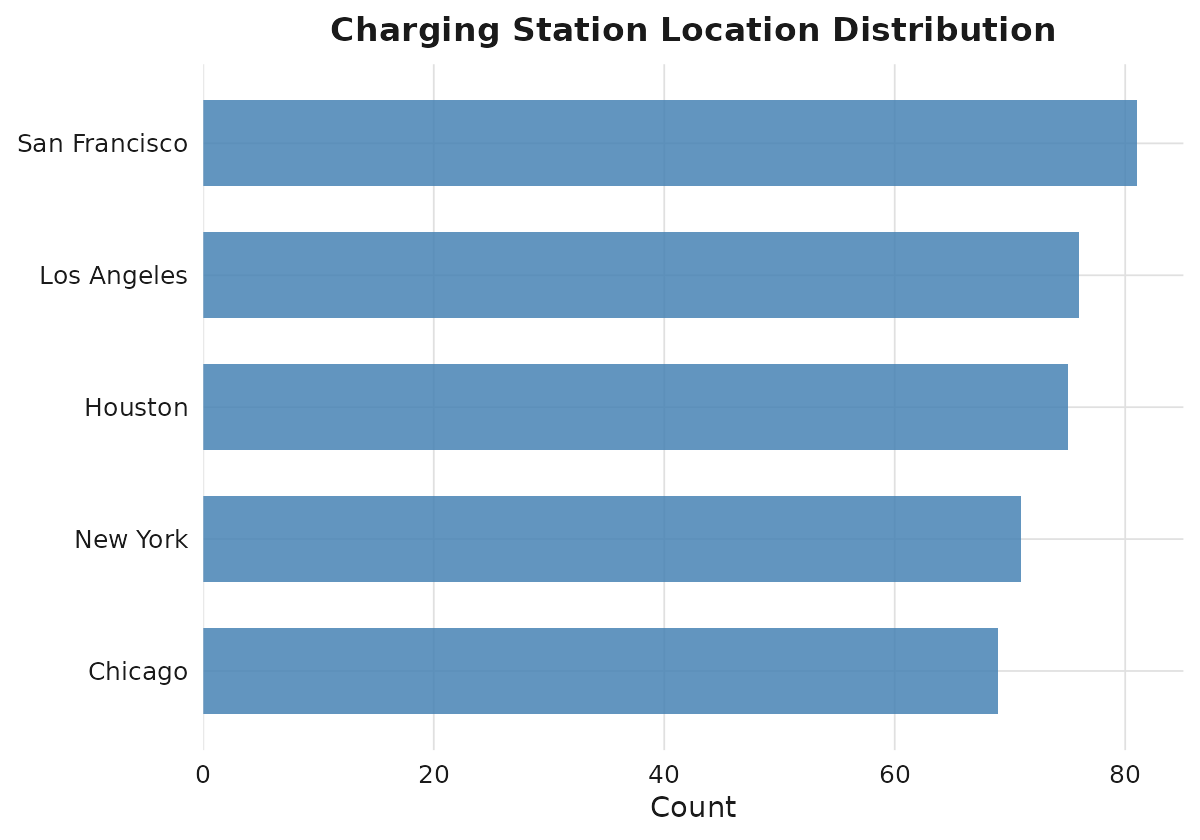


Charging Start Hour Distribution
------------------------------------- 


 


Statistic     Value
----------  -------
Count        372.00
Missing        0.00
Mean          11.54
Median        12.00
Std Dev        6.95
Min            0.00
Max           23.00
25th pct       6.00
75th pct      18.00



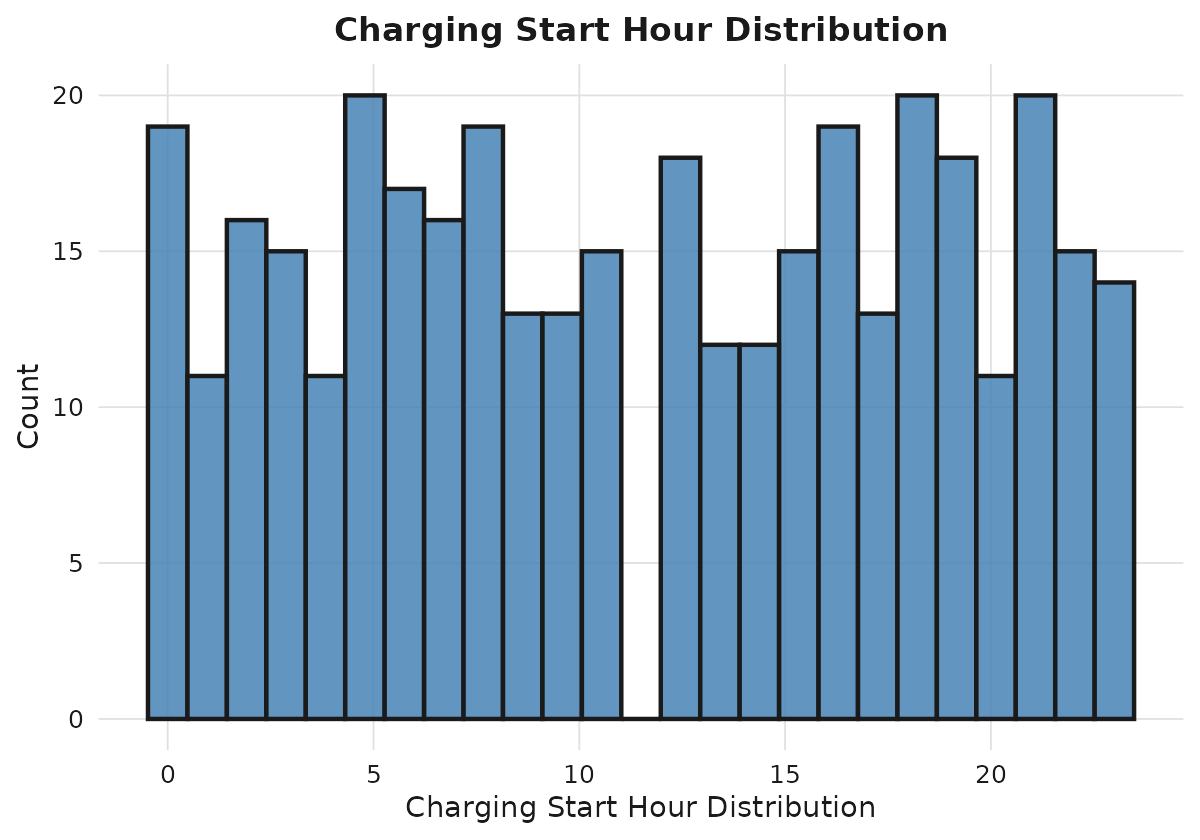


Charging Duration (Hours) Distribution
------------------------------------------- 


 


Statistic     Value
----------  -------
Count        372.00
Missing        0.00
Mean           2.23
Median         2.22
Std Dev        1.04
Min            0.42
Max            5.44
25th pct       1.37
75th pct       3.11



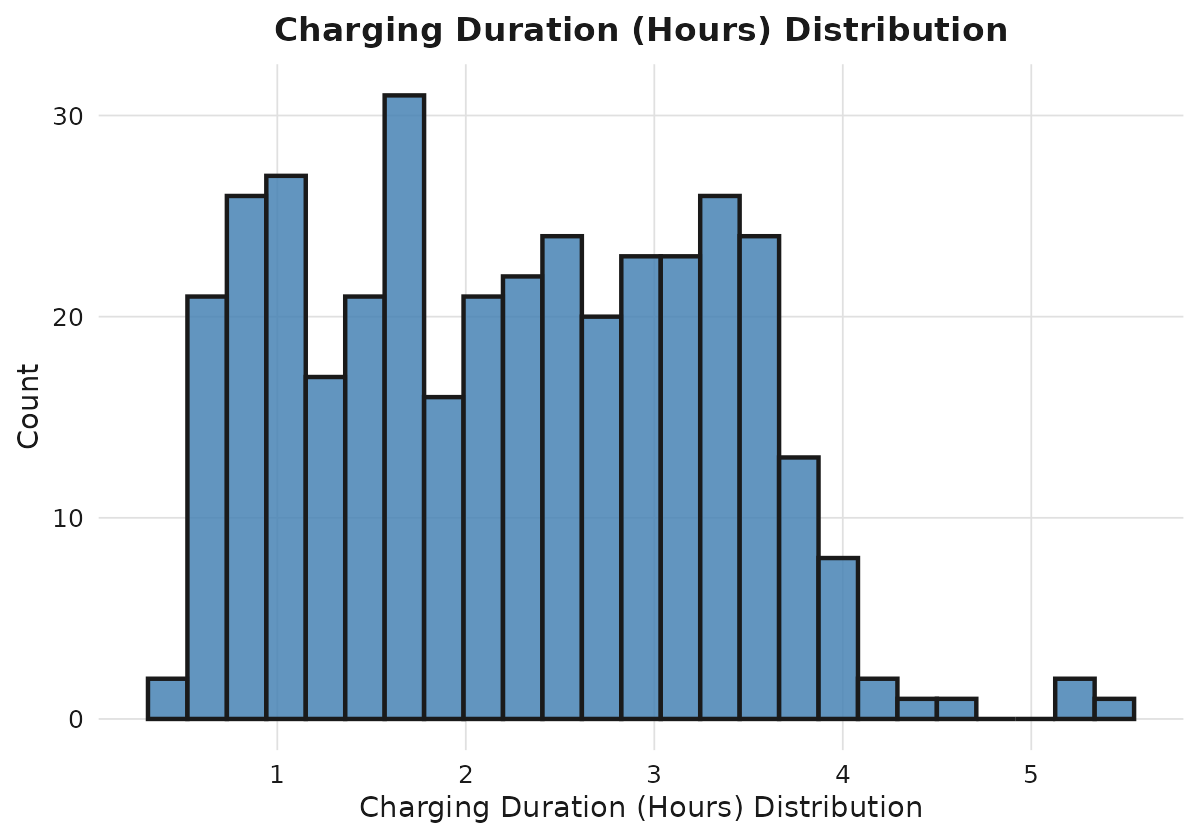


Energy Consumed (kWh) Distribution
--------------------------------------- 


 


Statistic     Value
----------  -------
Count        312.00
Missing       60.00
Mean          40.17
Median        40.47
Std Dev       18.62
Min            5.14
Max           79.36
25th pct      26.39
75th pct      53.37



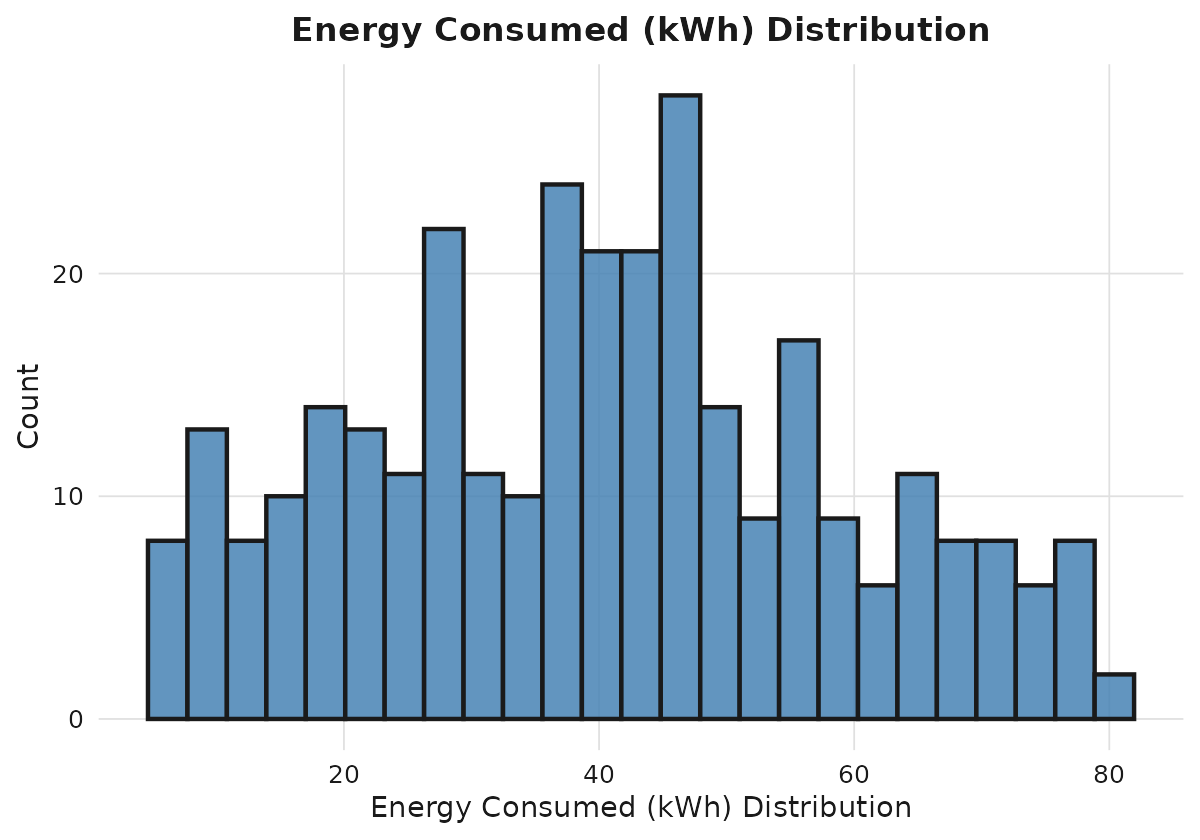


Charger Type Distribution
------------------------------ 


 


Value              Count   Percentage (%)
----------------  ------  ---------------
Level 1              134             36.0
DC Fast Charger      120             32.3
Level 2              118             31.7



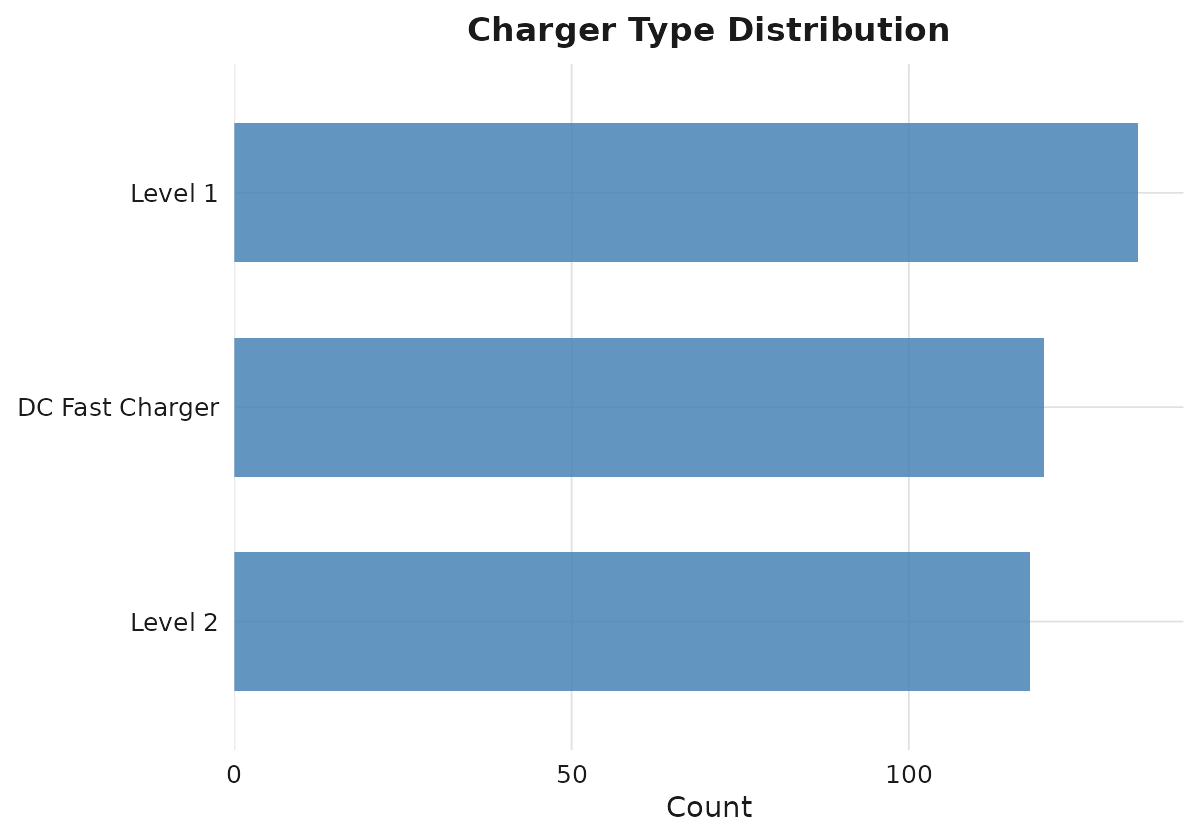


=== BIVARIATE ANALYSIS (CLEAN DATA) ===
══════════════════════════════════════════════════ 
I explore key pairwise relationships to identify directional signals across charging behaviour.

Charging Duration vs Energy Delivered — Charger Type: DC Fast Charger
------------------------------------------------------------------------ 
Longer sessions should raise delivered energy. 


 


Metric                 Value
-------------------  -------
Observations          99.000
Pearson r              0.079
Spearman rho           0.034
Slope (y ~ x)          1.465
R-squared (linear)     0.006



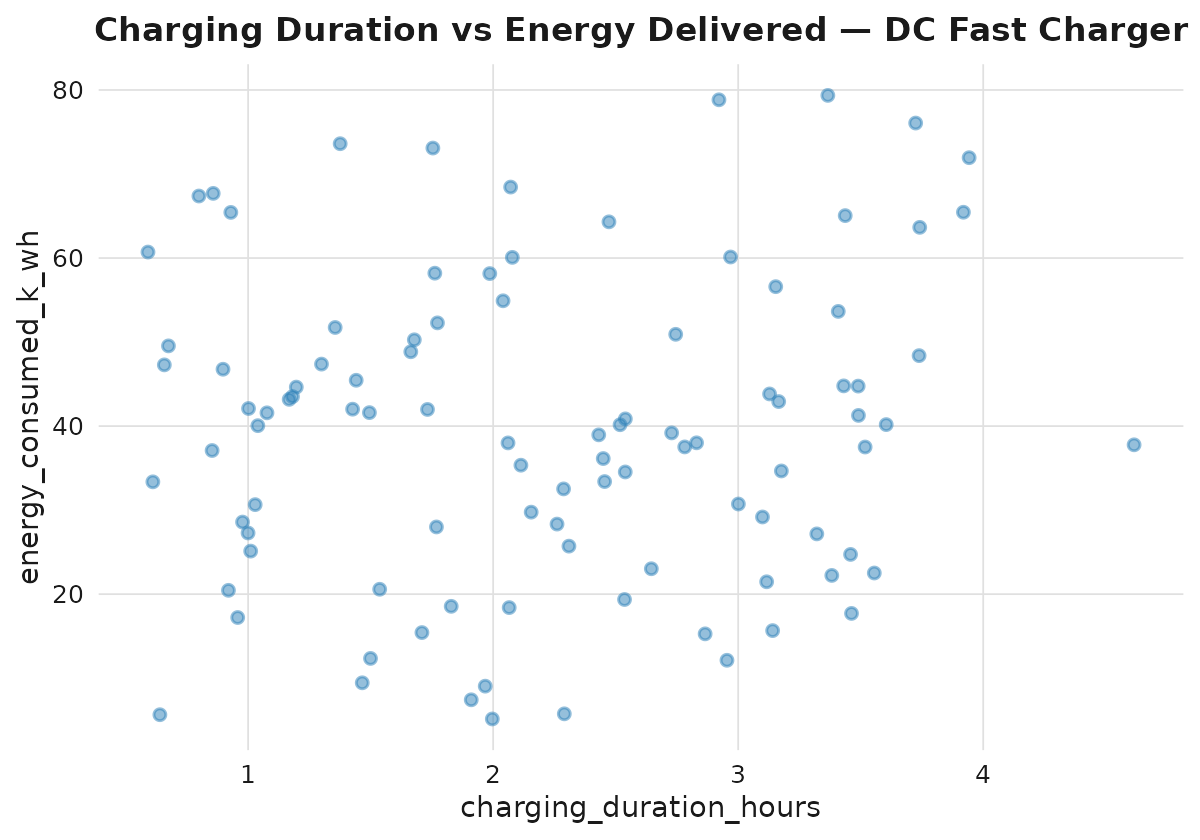


Charging Duration vs Energy Delivered — Charger Type: Level 1
---------------------------------------------------------------- 
Longer sessions should raise delivered energy. 


 


Metric                  Value
-------------------  --------
Observations          115.000
Pearson r               0.201
Spearman rho            0.180
Slope (y ~ x)           3.536
R-squared (linear)      0.040



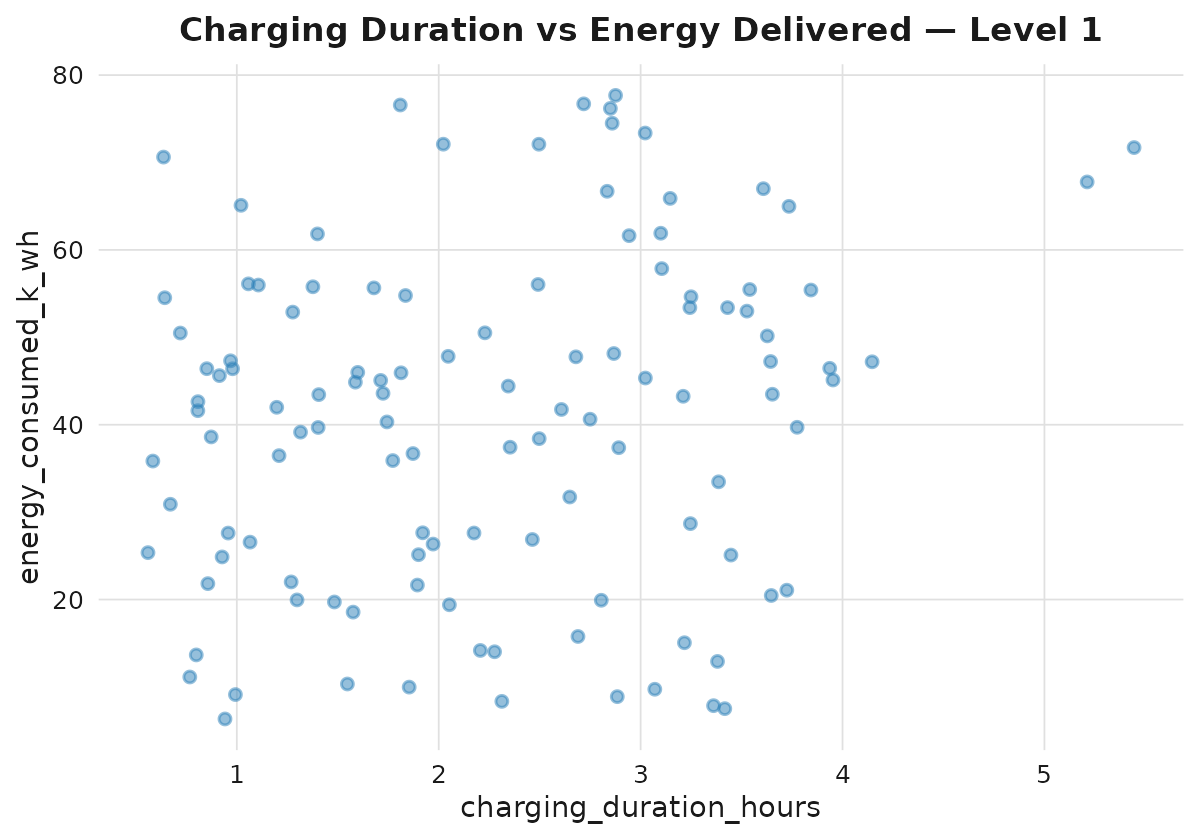


Charging Duration vs Energy Delivered — Charger Type: Level 2
---------------------------------------------------------------- 
Longer sessions should raise delivered energy. 


 


Metric                 Value
-------------------  -------
Observations          98.000
Pearson r              0.286
Spearman rho           0.268
Slope (y ~ x)          4.894
R-squared (linear)     0.082



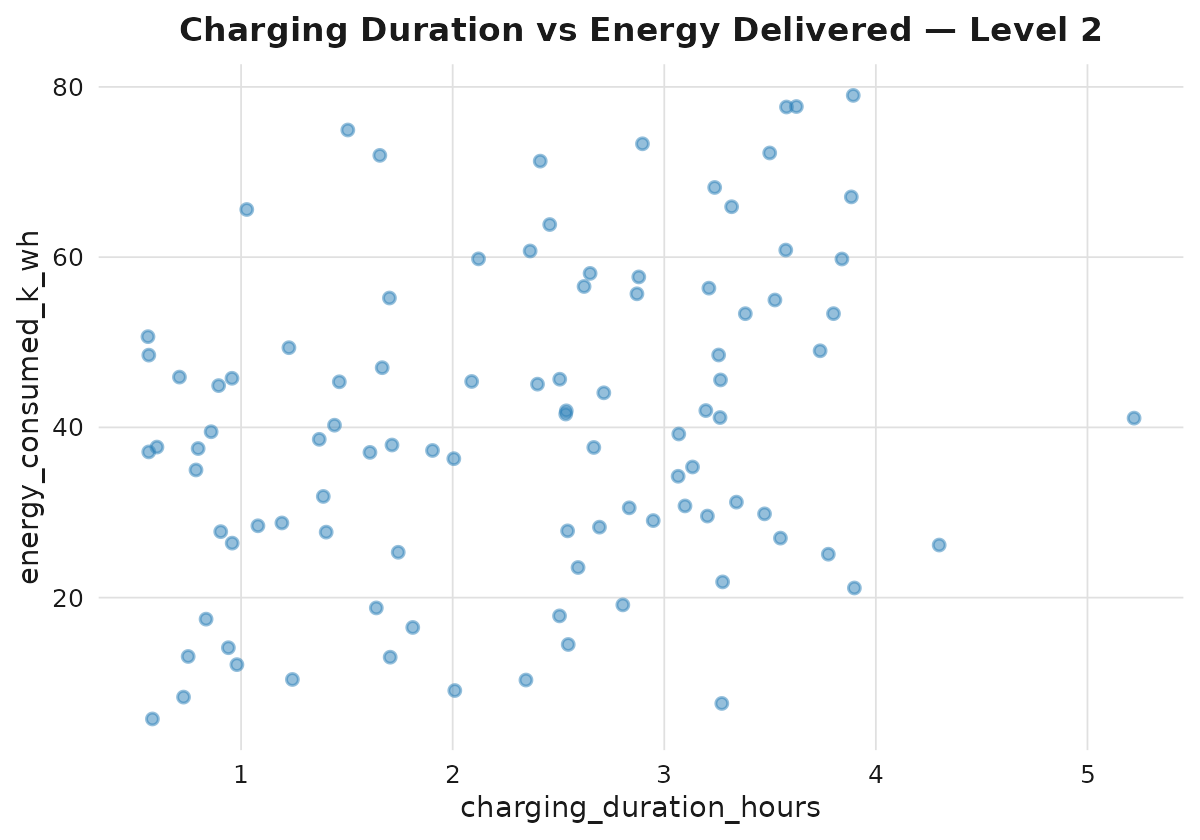


Charging Rate vs Energy Delivered — Charger Type: DC Fast Charger
-------------------------------------------------------------------- 
Higher power rates can accelerate energy delivered. 


 


Metric                 Value
-------------------  -------
Observations          96.000
Pearson r              0.012
Spearman rho           0.018
Slope (y ~ x)          0.016
R-squared (linear)     0.000



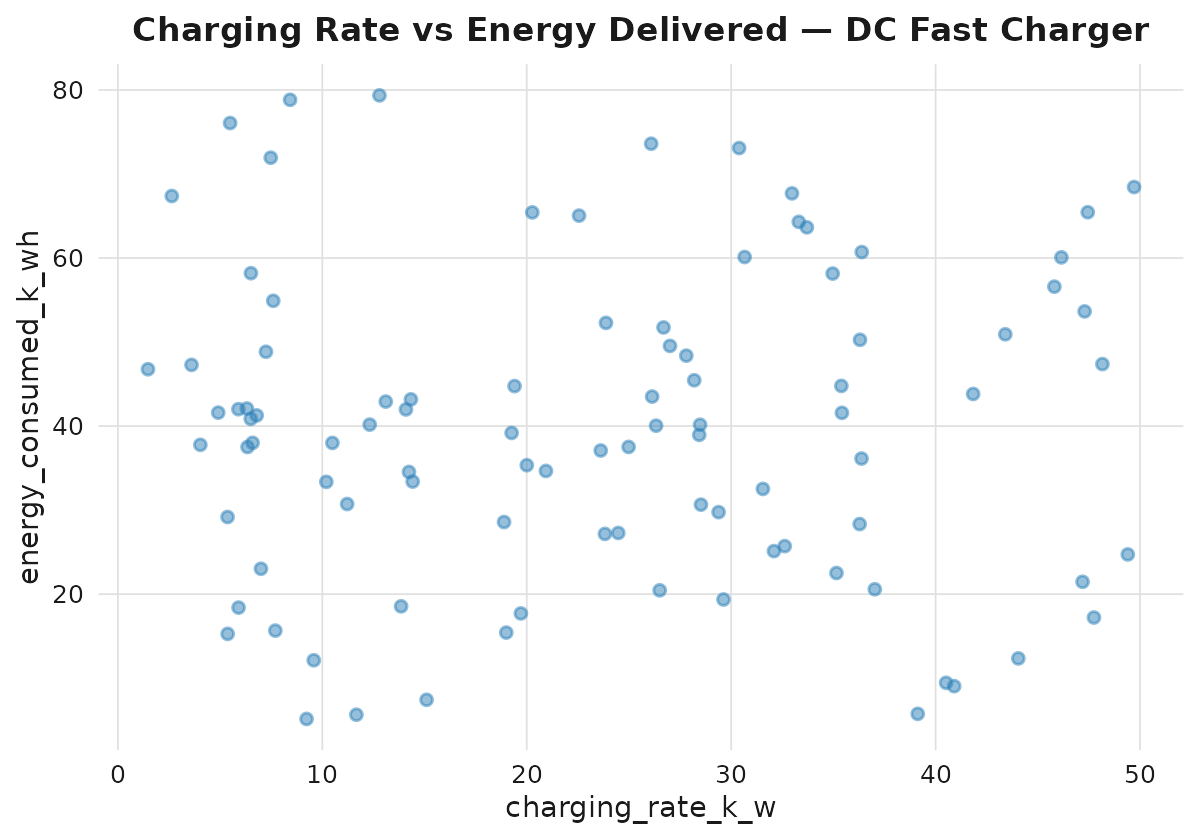


Charging Rate vs Energy Delivered — Charger Type: Level 1
------------------------------------------------------------ 
Higher power rates can accelerate energy delivered. 


 


Metric                  Value
-------------------  --------
Observations          109.000
Pearson r               0.040
Spearman rho            0.098
Slope (y ~ x)           0.047
R-squared (linear)      0.002



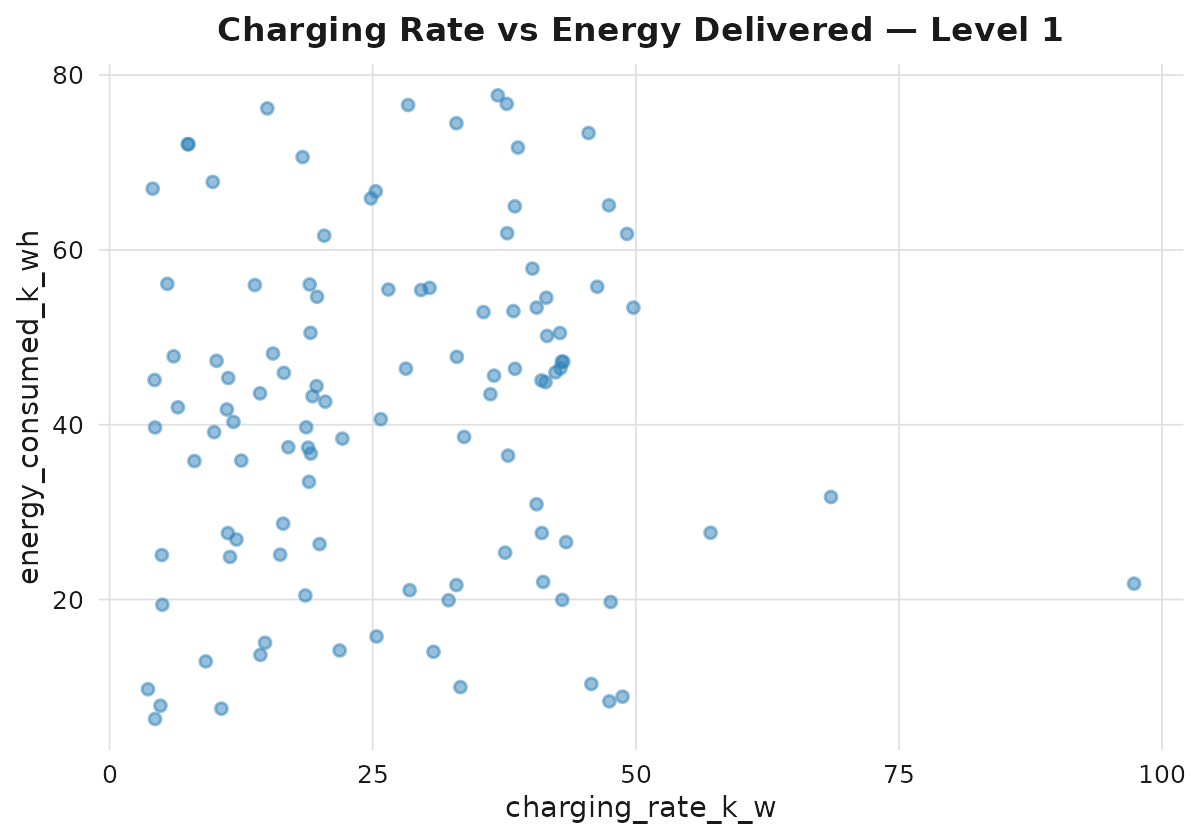


Charging Rate vs Energy Delivered — Charger Type: Level 2
------------------------------------------------------------ 
Higher power rates can accelerate energy delivered. 


 


Metric                 Value
-------------------  -------
Observations          90.000
Pearson r             -0.101
Spearman rho          -0.112
Slope (y ~ x)         -0.133
R-squared (linear)     0.010



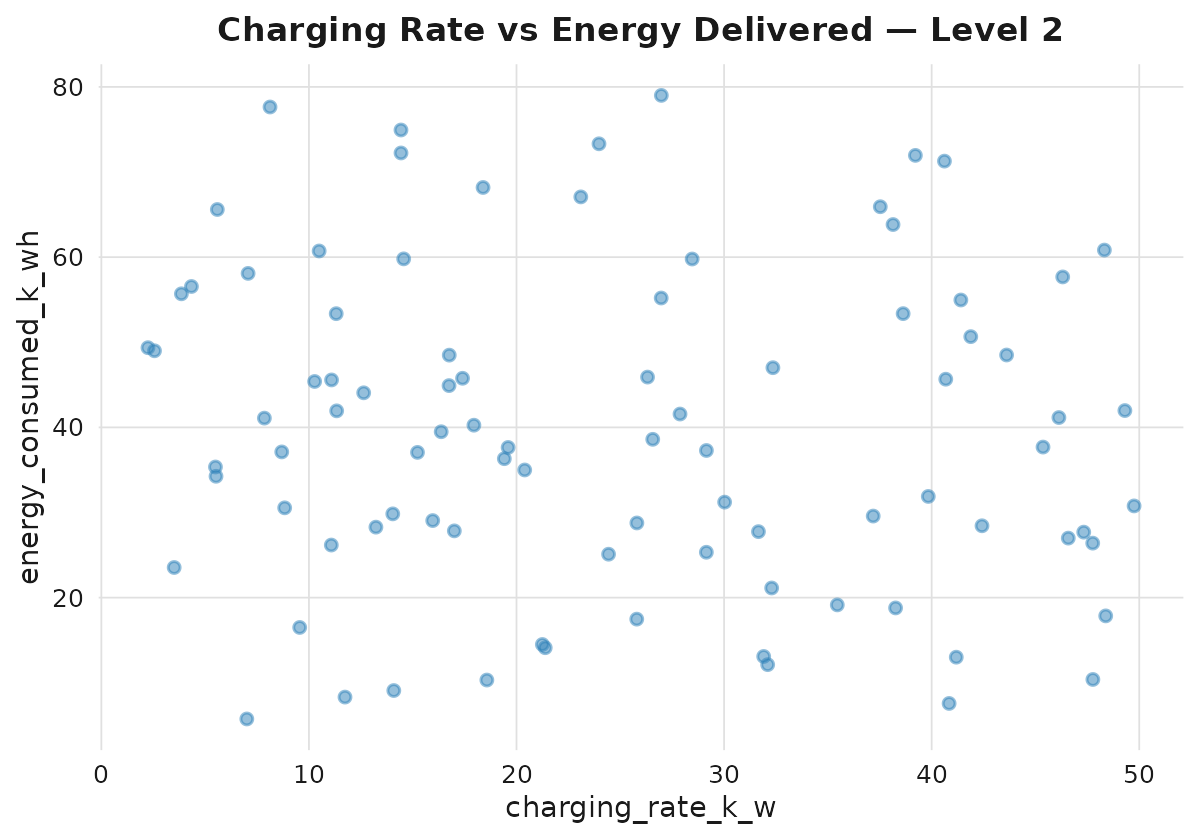


Energy Delivered vs Charging Cost — Charger Type: DC Fast Charger
-------------------------------------------------------------------- 
Delivered kWh typically drives the session cost. 


 


Metric                 Value
-------------------  -------
Observations          99.000
Pearson r             -0.120
Spearman rho          -0.098
Slope (y ~ x)         -0.076
R-squared (linear)     0.014



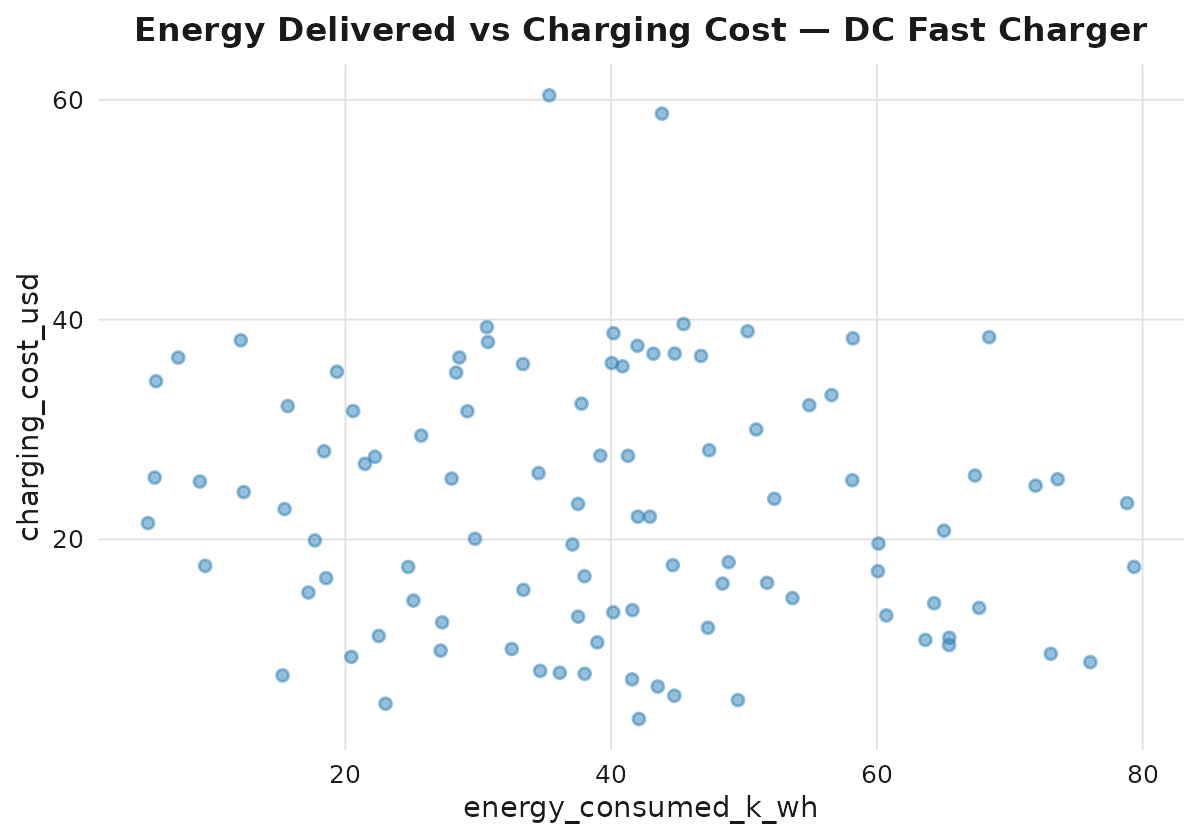


Energy Delivered vs Charging Cost — Charger Type: Level 1
------------------------------------------------------------ 
Delivered kWh typically drives the session cost. 


 


Metric                  Value
-------------------  --------
Observations          115.000
Pearson r               0.041
Spearman rho            0.051
Slope (y ~ x)           0.023
R-squared (linear)      0.002



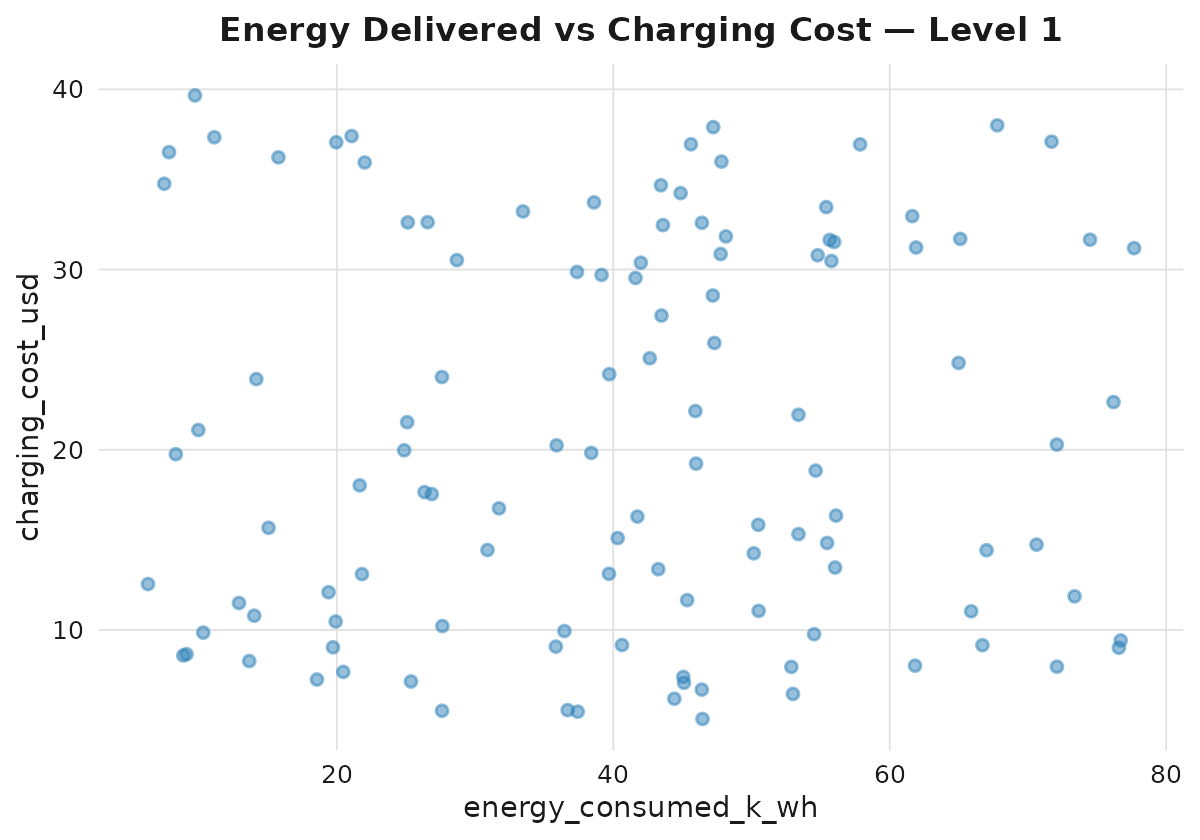


Energy Delivered vs Charging Cost — Charger Type: Level 2
------------------------------------------------------------ 
Delivered kWh typically drives the session cost. 


 


Metric                 Value
-------------------  -------
Observations          98.000
Pearson r             -0.047
Spearman rho          -0.060
Slope (y ~ x)         -0.028
R-squared (linear)     0.002



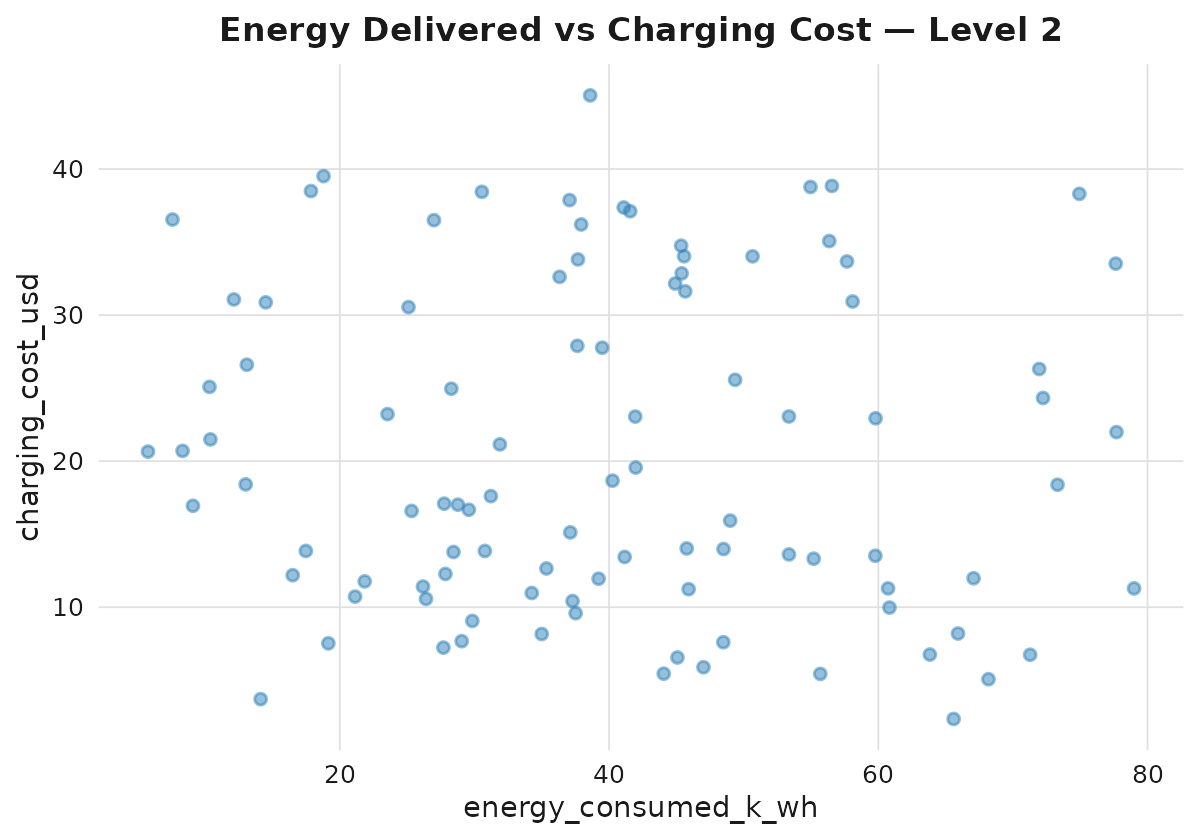


Charging Duration vs Charging Cost — Charger Type: DC Fast Charger
--------------------------------------------------------------------- 
Longer occupancy can lift spend and station utilisation. 


 


Metric                  Value
-------------------  --------
Observations          120.000
Pearson r               0.015
Spearman rho           -0.011
Slope (y ~ x)           0.173
R-squared (linear)      0.000



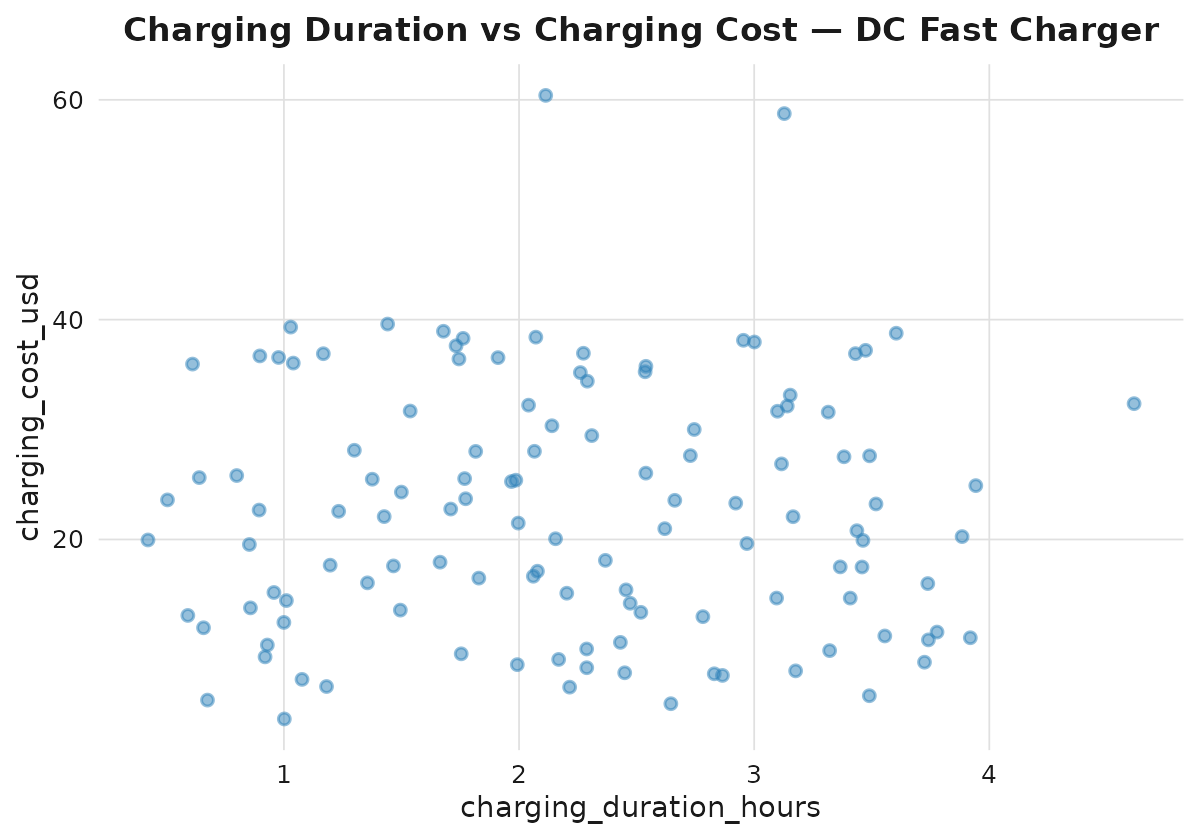


Charging Duration vs Charging Cost — Charger Type: Level 1
------------------------------------------------------------- 
Longer occupancy can lift spend and station utilisation. 


 


Metric                  Value
-------------------  --------
Observations          134.000
Pearson r               0.112
Spearman rho            0.088
Slope (y ~ x)           1.115
R-squared (linear)      0.013



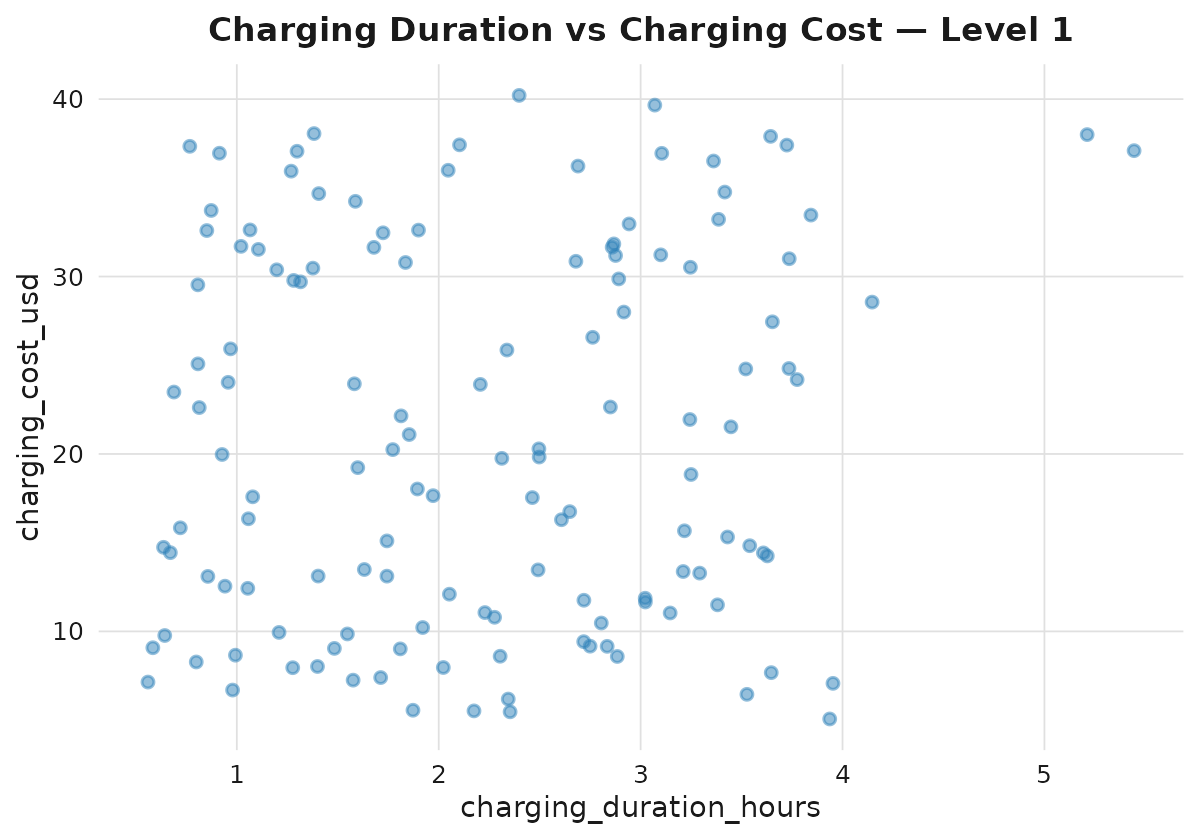


Charging Duration vs Charging Cost — Charger Type: Level 2
------------------------------------------------------------- 
Longer occupancy can lift spend and station utilisation. 


 


Metric                  Value
-------------------  --------
Observations          118.000
Pearson r              -0.005
Spearman rho           -0.024
Slope (y ~ x)          -0.053
R-squared (linear)      0.000



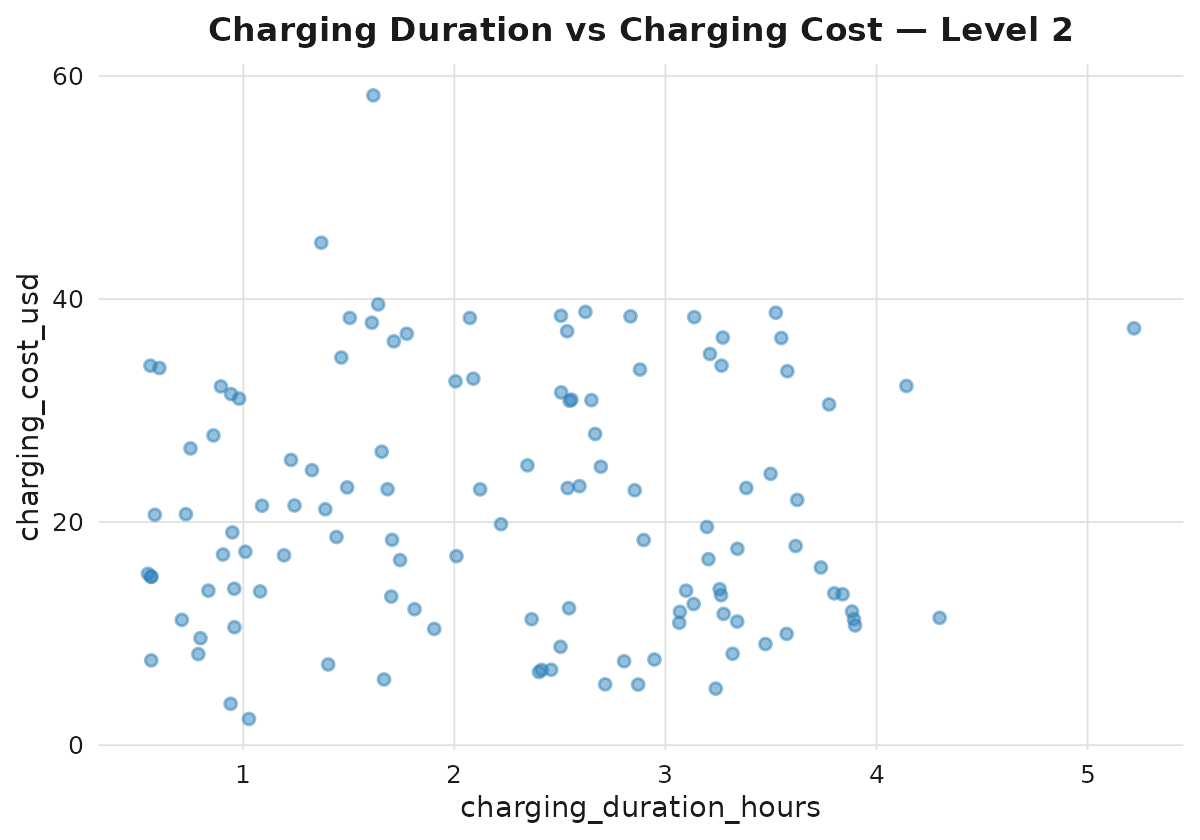


Categorical drivers versus numeric outcomes:
---------------------------------------- 

Energy Delivered by Charger Type
------------------------------------- 
Connector technology influences throughput and dwell time. 


 


Category           Count   Percentage (%)   Mean   Median   Std Dev
----------------  ------  ---------------  -----  -------  --------
Level 1              115             36.9   40.8     43.2      19.1
DC Fast Charger       99             31.7   39.5     40.0      18.3
Level 2               98             31.4   40.1     38.9      18.5



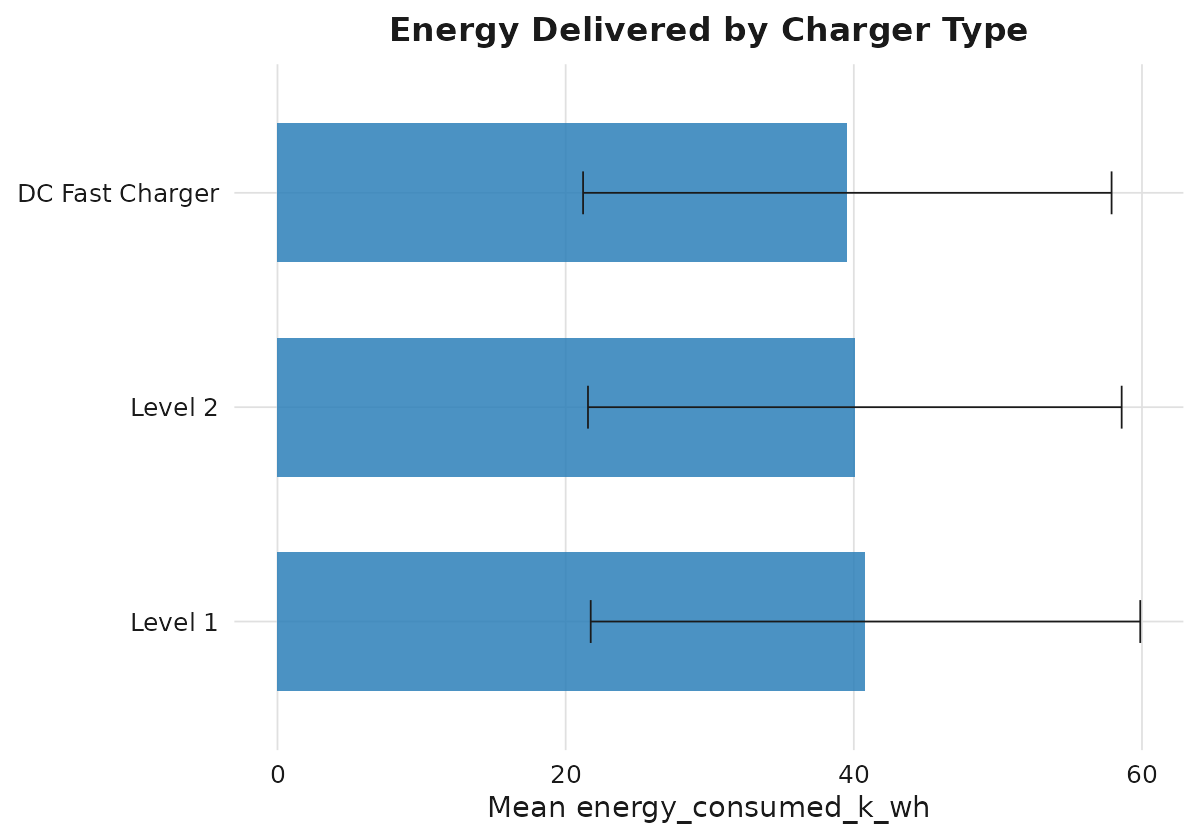


Charging Cost by User Type
------------------------------- 
Segment mix indicates monetisation profiles. 


 


Category                  Count   Percentage (%)   Mean   Median   Std Dev
-----------------------  ------  ---------------  -----  -------  --------
Commuter                    143             38.4   20.4     18.8      10.3
Casual Driver               123             33.1   23.0     23.2      11.0
Long-Distance Traveler      106             28.5   21.8     19.7      11.8



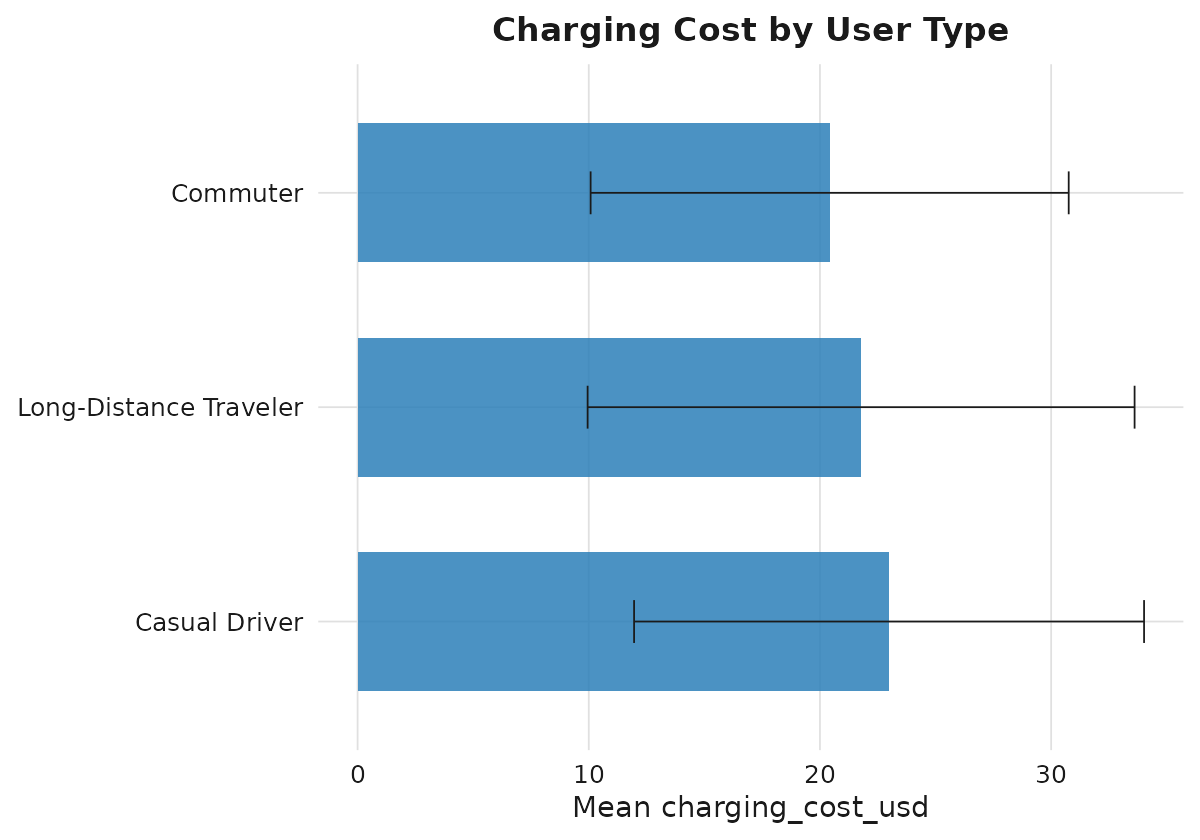


Charging Duration by Day of Week
------------------------------------- 
Weekday versus weekend usage signals scheduling opportunities. 


 


Category     Count   Percentage (%)   Mean   Median   Std Dev
----------  ------  ---------------  -----  -------  --------
Monday          65             17.5   2.22     2.23      1.06
Sunday          57             15.3   1.93     1.73      0.99
Saturday        54             14.5   2.19     2.16      1.10
Friday          53             14.2   2.21     2.22      0.96
Wednesday       52             14.0   2.44     2.51      1.06
Tuesday         51             13.7   2.32     2.51      0.97
Thursday        40             10.8   2.40     2.31      1.12



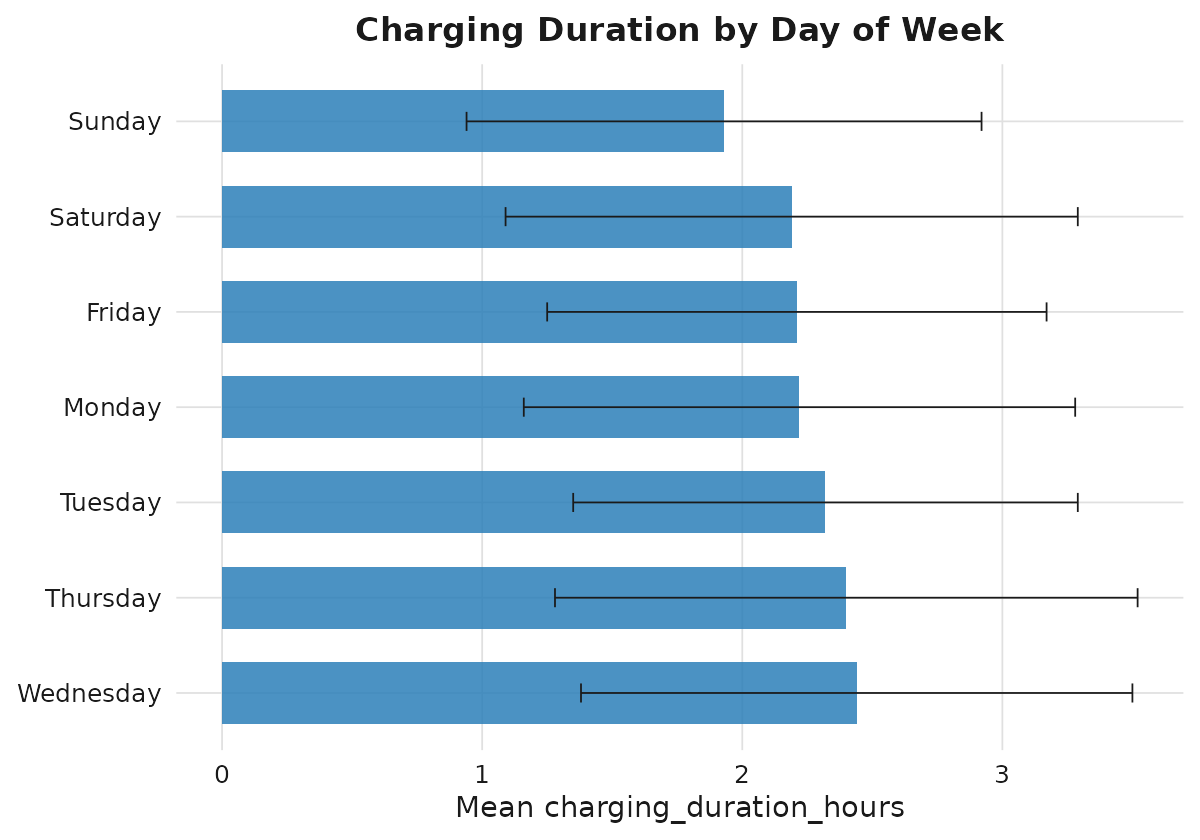


=== CHARGING ACTIVITY BY DAYPART ===
══════════════════════════════════════════════════ 


 


Daypart               Sessions   TotalEnergy_kWh   AvgEnergy_kWh   Share Sessions (%)   Share Energy (%)
-------------------  ---------  ----------------  --------------  -------------------  -----------------
Late Night (00-05)          92              3177            41.8                 24.7               25.3
Morning (06-11)             93              3392            40.4                 25.0               25.3
Afternoon (12-17)           89              2716            37.2                 23.9               25.3
Evening (18-23)             98              3249            41.1                 26.3               25.3

ℹ Use these totals to contrast night-time (00-05) with daytime periods before drawing campaign conclusions.


In [2]:
# 1. SETUP AND CONFIGURATION ----
# I clear the R environment to ensure a clean start
rm(list = ls())

# I configure the R session settings for optimal output formatting
options(
  scipen = 999,
  stringsAsFactors = FALSE,
  digits = 3,
  width = 150
)

# 2. LOAD LIBRARIES
suppressPackageStartupMessages({
  if (!require("pacman", quietly = TRUE)) {
    install.packages("pacman", quiet = TRUE, repos = "https://cran.rstudio.com/")
  }
  
pacman::p_load(
    # I rely on these core packages
    tidyverse,

    # I include these utilities
    janitor,
    knitr,
    gridExtra,

    # I use these for distribution metrics
    moments
  )
})

# I ensure dplyr verbs stay available even if tidyverse attachment is skipped in some environments
if (!"package:dplyr" %in% search()) {
  suppressPackageStartupMessages(library(dplyr))
}

# 3. CUSTOM FUNCTIONS
print_table <- function(data, title = NULL, align = NULL) {
  # I render a small table with an optional heading and default alignment
  if (!is.null(title)) {
    cat("\n", title, "\n", sep = "")
    cat(strrep("─", nchar(title)), "\n")
  }
  
  if (is.null(align)) {
    align <- rep("r", ncol(data))
    align[1] <- "l"
  }
  
  data %>%
    kable(format = "simple", align = align) %>%
    print()
  
  cat("\n")
}

display_image_inline <- function(path, width = 60) {
  if (!file.exists(path)) {
    cat(sprintf("\n⚠ Generated image not found: %s\n", path))
    return(invisible(FALSE))
  }

  displayed <- FALSE

  if (requireNamespace("cli", quietly = TRUE)) {
    if (cli::is_dynamic_tty() && cli::num_ansi_colors() > 1) {
      success <- tryCatch(
        {
          cat("\n")
          cli::ansi_image(path, width = width)
          cat("\n")
          TRUE
        },
        error = function(e) FALSE
      )
      displayed <- displayed || success
    }
  }

  if (!displayed && requireNamespace("IRdisplay", quietly = TRUE)) {
    success <- tryCatch(
      {
        IRdisplay::display_png(file = path)
        TRUE
      },
      error = function(e) FALSE
    )
    displayed <- displayed || success
  }

  if (!displayed && interactive() && requireNamespace("rstudioapi", quietly = TRUE)) {
    if (rstudioapi::isAvailable()) {
      rstudioapi::viewer(path)
      displayed <- TRUE
    }
  }

  if (!displayed) {
    cat(sprintf("\nℹ Image saved to: %s\n", normalizePath(path)))
  }

  invisible(displayed)
}

render_plot_inline <- function(plot_obj, filename = NULL, width = 4, height = 2.8, bg = "white") {
  inline_env <- interactive() || isTRUE(getOption("knitr.in.progress"))

  if (!is.null(filename)) {
    ggsave(filename, plot = plot_obj, width = width, height = height, bg = bg)
    if (!inline_env) {
      display_image_inline(filename)
      return(invisible(plot_obj))
    }
  }

  if (inline_env) {
    old_width <- getOption("repr.plot.width", NULL)
    old_height <- getOption("repr.plot.height", NULL)
    options(repr.plot.width = width, repr.plot.height = height)
    on.exit({
      if (is.null(old_width)) {
        options(repr.plot.width = NULL)
      } else {
        options(repr.plot.width = old_width)
      }
      if (is.null(old_height)) {
        options(repr.plot.height = NULL)
      } else {
        options(repr.plot.height = old_height)
      }
    }, add = TRUE)
    print(plot_obj)
  } else {
    temp_path <- if (is.null(filename)) tempfile("plot_inline_", fileext = ".png") else filename
    if (is.null(filename)) {
      ggsave(temp_path, plot = plot_obj, width = width, height = height, bg = bg)
      display_image_inline(temp_path)
    }
  }

  invisible(plot_obj)
}

detect_theme_variant <- function() {
  kaggle_theme <- tolower(Sys.getenv("KAGGLE_THEME", ""))
  if (kaggle_theme %in% c("dark", "light")) {
    return(kaggle_theme)
  }

  kaggle_dark_mode <- tolower(Sys.getenv("KAGGLE_DARK_MODE", ""))
  if (kaggle_dark_mode %in% c("1", "true", "dark")) {
    return("dark")
  }

  if (requireNamespace("rstudioapi", quietly = TRUE)) {
    if (rstudioapi::isAvailable() && rstudioapi::hasFun("getThemeInfo")) {
      info <- tryCatch(rstudioapi::getThemeInfo(), error = function(e) NULL)
      if (!is.null(info) && isTRUE(info$dark)) {
        return("dark")
      }
      if (!is.null(info) && identical(info$dark, FALSE)) {
        return("light")
      }
    }
  }

  "light"
}

plot_correlation_heatmap <- function(cor_matrix, title, filename = NULL) {
  theme_variant <- detect_theme_variant()
  axis_color <- if (identical(theme_variant, "dark")) "#F5F5F5" else "#1A1A1A"
  plot_bg <- if (identical(theme_variant, "dark")) "#1F1F1F" else "white"
  grid_color <- if (identical(theme_variant, "dark")) "#3A3A3A" else "#E0E0E0"

  cor_df <- cor_matrix %>%
    as.data.frame() %>%
    tibble::rownames_to_column("Var1") %>%
    pivot_longer(-Var1, names_to = "Var2", values_to = "correlation")

  heatmap_plot <- cor_df %>%
    mutate(
      Var1 = factor(Var1, levels = unique(Var1)),
      Var2 = factor(Var2, levels = unique(Var1)),
      label = sprintf("%.2f", correlation),
      label_color = if_else(abs(correlation) > 0.5, "white", "black")
    ) %>%
    ggplot(aes(x = Var1, y = Var2, fill = correlation)) +
    geom_tile(color = "white") +
    geom_text(aes(label = label, color = label_color), size = 1.4) +
    scale_fill_gradient2(
      low = "#B2182B",
      mid = "#FFFFFF",
      high = "#2166AC",
      midpoint = 0,
      limits = c(-1, 1),
      name = "Correlation"
    ) +
    scale_color_identity(guide = "none") +
    labs(title = title, x = NULL, y = NULL) +
    theme_minimal(base_size = 7) +
    theme(
      plot.background = element_rect(fill = plot_bg, color = NA),
      panel.background = element_rect(fill = plot_bg, color = NA),
      panel.grid.major = element_line(color = grid_color, linewidth = 0.3),
      panel.grid.minor = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, color = axis_color, size = 5),
      axis.text.y = element_text(color = axis_color, size = 5),
      plot.title = element_text(face = "bold", hjust = 0.5, color = axis_color, size = 8),
      axis.title = element_blank()
    )

  inline_env <- interactive() || isTRUE(getOption("knitr.in.progress"))

  if (!is.null(filename)) {
    ggsave(filename, plot = heatmap_plot, width = 4, height = 2.8, bg = plot_bg)
    if (!inline_env) {
      display_image_inline(filename)
      return(invisible(heatmap_plot))
    }
  }

  if (inline_env) {
    print(heatmap_plot)
  } else {
    temp_path <- if (is.null(filename)) tempfile("correlation_heatmap_", fileext = ".png") else filename
    if (is.null(filename)) {
      ggsave(temp_path, plot = heatmap_plot, width = 4, height = 2.8, bg = plot_bg)
    }
    display_image_inline(temp_path)
  }

  invisible(heatmap_plot)
}

# 4. DATA LOADING
# I handle flexible data loading for both Kaggle and local environments
if (file.exists("/kaggle/input")) {
  csv_files <- list.files("/kaggle/input", pattern = "\\.csv$", 
                         recursive = TRUE, full.names = TRUE)
  if (length(csv_files) == 0) stop("No CSV file found in Kaggle input.")
  data_path <- csv_files[1]
  cat("Loading data from Kaggle:", basename(data_path), "\n")
} else {
  data_path <- "ev_charging_patterns.csv"
  if (!file.exists(data_path)) {
    stop("Data file 'ev_charging_patterns.csv' not found in project directory.")
  }
  cat("Loading local data file:", data_path, "\n")
}

data_raw <- read_csv(data_path, 
                    show_col_types = FALSE,
                    locale = locale(encoding = "UTF-8"))

data <- data_raw %>% clean_names()

# I provide a quick data overview
cat("Dataset dimensions:", nrow(data), "rows x", ncol(data), "columns\n\n")
# I keep these ID columns out of further analysis
id_columns <- c("user_id", "charging_station_id")

# I configure validation thresholds and tolerances (tuned for an EV/PHEV mix)
validation_params <- list(
  min_battery_kwh = 4,                # I allow smaller PHEV packs before escalating
  soc_noise_tolerance_pct = 4,        # I broaden tolerance for SOC noise or round trips
  warn_temp_min_c = -40,              # I treat readings outside this band as warnings
  warn_temp_max_c = 55,
  min_rate_kw = 0.2,                  # I only warn if the derived rate falls below a trickle
  energy_soc_warning_pct = 30,        # I escalate when SOC and energy diverge beyond 30%
  energy_soc_invalid_pct = 40,        # I hard fail once the gap exceeds 40%
  station_power_multiplier = 1.15     # I allow a 15% headroom over the configured site limit
)

validation_rules <- tibble::tribble(
  ~rule_id,             ~rule_label,            ~rule_description,                                                                    ~rule_condition,                                                             ~print_order,
  "soc_high",           "SOC_RANGE_HIGH",       "SOC must not exceed 100%",                                                          "state_of_charge_end_percent > 100",                                               1,
  "soc_low",            "SOC_RANGE_LOW",        "SOC must not fall below 0%",                                                        "state_of_charge_start_percent < 0",                                              2,
  "soc_discharge",      "SOC_MONOTONIC",        "SOC should increase during charging (±4% tolerance)",                               "state_of_charge_start_percent > state_of_charge_end_percent + soc_noise_tolerance_pct", 3,
  "soc_energy_gap",     "SOC_ENERGY_GAP",       "SOC delta vs delivered energy gap >40% (warning raised above 30%)",                 "discrepancy_pct > energy_soc_invalid_pct",                                       4,
  "battery",            "BATTERY_POSITIVE",     "Battery capacity must be positive",                                                 "battery_capacity_k_wh <= 0",                                                     5,
  "energy",             "ENERGY_POSITIVE",      "Energy consumed must be positive",                                                  "energy_consumed_k_wh <= 0",                                                      6,
  "time",               "TIME_ORDER",           "Start time must come before end time",                                              "charging_start_time >= charging_end_time while duration <= 0",                  9,
  "duration",           "DURATION_POSITIVE",    "Charging duration must be positive",                                                "charging_duration_hours <= 0",                                                 10,
  "distance",           "DISTANCE_NON_NEG",     "Distance driven since last charge must not be negative",                            "distance_driven_since_last_charge_km < 0",                                     11,
  "age",                "AGE_NON_NEGATIVE",     "Vehicle age must not be negative",                                                  "vehicle_age_years < 0",                                                        12,
  "battery_too_small",  "BATTERY_MIN_4KWH",     "Battery capacity under 4 kWh (warning only — retain record, highlight for review)", "battery_capacity_k_wh < 4",                                                     13,
  "rate_low",           "RATE_MIN_0_2KW",       "Average charging rate below 0.2 kW (warning only — retain record, highlight for review)", "charging_rate_k_w <= 0.2",                                               14,
  "age_high",           "AGE_MAX_30",           "Vehicle age above 30 years (warning only — retain record, highlight for review)",   "vehicle_age_years > 30",                                                       15,
  "soc_energy_gap_warn","SOC_ENERGY_GAP_WARN",  "SOC delta vs delivered energy gap between 30% and 40% (warning range)",              "discrepancy_pct > energy_soc_warning_pct",                                     16,
  "temp_low",           "TEMP_MIN_-40",         "Ambient temperature below -40 °C (warning only)",                                   "temperature_c < warn_temp_min_c",                                              19,
  "temp_high",          "TEMP_MAX_55",          "Ambient temperature above 55 °C (warning only)",                                    "temperature_c > warn_temp_max_c",                                              20,
  "cost_credit",        "COST_CREDIT",          "Charging cost recorded as negative (credit/refund) — review source billing",        "charging_cost_usd < 0",                                                        21
)

# 5. DATA OVERVIEW ----
cat("\n╔════════════════════════════════════════════════════╗\n")
cat("║     COMPREHENSIVE EV CHARGING DATA ANALYSIS        ║\n")
cat("║         FOR AD STRATEGY OPTIMIZATION               ║\n")
cat("╚════════════════════════════════════════════════════════╝\n\n")

# I display basic dataset information
cat("\nDataset:", basename(data_path), "\n")
cat("Dimensions:", format(nrow(data), big.mark = ","), "rows x", ncol(data), "columns\n")
if ("charging_start_time" %in% names(data)) {
  date_range <- range(data$charging_start_time, na.rm = TRUE)
  cat("Date range:", as.character(date_range[1]), "to", as.character(date_range[2]), "\n")
}

# 6. DATA STRUCTURE & QUALITY
# I create a simple summary of column data types
type_counts <- table(sapply(data, function(x) class(x)[1]))
col_summary <- data.frame(
  "Data Type" = names(type_counts),
  Count = as.numeric(type_counts),
  Percentage = sprintf("%.1f%%", 100 * type_counts / sum(type_counts))
) %>%
  arrange(desc(Count))

print_table(col_summary, "\nColumn Types Summary")

# I check for duplicate records
n_duplicates <- sum(duplicated(data))
duplicate_pct <- round(n_duplicates / nrow(data) * 100, 2)
cat("\nDuplicate records check:\n")
cat(strrep("─", 30), "\n")
cat("Total duplicate rows:", format(n_duplicates, big.mark = ","),
    sprintf("(%.2f%%)", duplicate_pct), "\n")
if (n_duplicates > 0) {
  cat("⚠ Warning: dataset contains duplicate records\n")
} else {
  cat("✓ No duplicate records found\n")
}

# 7. CALCULATE BRIEF STATISTICS BEFORE CLEANING
cat("\n=== BRIEF STATISTICS BEFORE THE IMPOSSIBLE-VALUE FILTER ===\n")
cat(strrep("═", 50), "\n")

# I calculate key statistics on raw data for comparison
numeric_before <- data %>%
  select(where(is.numeric), -any_of(id_columns))

stats_before <- numeric_before %>%
  pivot_longer(everything(), names_to = "variable", values_to = "value") %>%
  group_by(variable) %>%
  summarise(
    n = n(),
    missing = sum(is.na(value)),
    mean = round(mean(value, na.rm = TRUE), 2),
    median = round(median(value, na.rm = TRUE), 2),
    sd = round(sd(value, na.rm = TRUE), 2),
    min = round(min(value, na.rm = TRUE), 2),
    max = round(max(value, na.rm = TRUE), 2),
    q25 = round(quantile(value, 0.25, na.rm = TRUE), 2),
    q75 = round(quantile(value, 0.75, na.rm = TRUE), 2),
    .groups = "drop"
  )

print_table(stats_before)

# I compute the correlation matrix on raw numeric data (pre-cleaning)
cor_before <- NULL
if (ncol(numeric_before) >= 2) {
  cor_before <- cor(numeric_before, use = "pairwise.complete.obs")
}

# I immediately visualize the pre-cleaning correlations
cat("\n=== CORRELATION HEATMAP (RAW DATA) ===\n")
cat(strrep("═", 50), "\n")

if (!is.null(cor_before)) {
  cat("\nCorrelation matrix (raw data):\n")
  cat(strrep("─", 30), "\n")
  plot_correlation_heatmap(cor_before, "Correlation Heatmap (Raw Data)")
  cat("✓ Correlation heatmap (raw data) rendered inline\n")
} else {
  cat("\nCorrelation matrix (raw data) skipped — fewer than two numeric columns available.\n")
}

# 8. HANDLE IMPOSSIBLE VALUES
cat("\n=== DATA CLEANING: REMOVING IMPOSSIBLE VALUES ===\n")
cat(strrep("═", 50), "\n")

# I document validation thresholds and their justification
cat("\nValidation rules applied (grounded in domain knowledge):\n")
cat(strrep("─", 40), "\n")
validation_rules %>%
  arrange(print_order) %>%
  mutate(rule_line = sprintf("• [%s]\n    %s\n    Condition: %s\n\n", rule_label, rule_description, rule_condition)) %>%
  pull(rule_line) %>%
  purrr::walk(cat)

# I create flags for impossible values with the documented thresholds
  data_flagged <- data %>%
    mutate(
      # I perform temporal validation
      invalid_time = if_else(
        !is.na(charging_start_time) & !is.na(charging_end_time),
        charging_start_time >= charging_end_time & (is.na(charging_duration_hours) | charging_duration_hours <= 0),
        FALSE
      ),
      invalid_duration = charging_duration_hours <= 0,

      # I apply battery/SOC validation
      invalid_soc_high = state_of_charge_end_percent > 100,
      invalid_soc_low = state_of_charge_start_percent < 0,
      invalid_soc_discharge = state_of_charge_start_percent > (state_of_charge_end_percent + validation_params$soc_noise_tolerance_pct),
      invalid_battery = battery_capacity_k_wh <= 0,
      warn_battery_too_small = battery_capacity_k_wh < validation_params$min_battery_kwh,

      # I perform energy validation
      invalid_energy = energy_consumed_k_wh <= 0,
      avg_rate_derived = if_else(
        charging_duration_hours > 0,
        energy_consumed_k_wh / charging_duration_hours,
        NA_real_
      ),
      warn_rate_low = charging_rate_k_w <= validation_params$min_rate_kw &
        (is.na(avg_rate_derived) | avg_rate_derived <= validation_params$min_rate_kw),
      theoretical_energy_calc = charging_duration_hours * charging_rate_k_w,
      soc_change = if_else(
        !is.na(state_of_charge_end_percent) & !is.na(state_of_charge_start_percent),
        state_of_charge_end_percent - state_of_charge_start_percent,
        NA_real_
      ),
      expected_energy = if_else(
        !is.na(soc_change) & !is.na(battery_capacity_k_wh),
        (soc_change / 100) * battery_capacity_k_wh,
        NA_real_
      ),
      energy_discrepancy = if_else(
        !is.na(expected_energy) & !is.na(energy_consumed_k_wh),
        abs(energy_consumed_k_wh - expected_energy),
        NA_real_
      ),
      discrepancy_pct = if_else(
        !is.na(expected_energy) & expected_energy != 0,
        (energy_discrepancy / expected_energy) * 100,
        NA_real_
      ),
      invalid_soc_energy_gap = !is.na(discrepancy_pct) & discrepancy_pct > validation_params$energy_soc_invalid_pct,
      warn_soc_energy_gap = !is.na(discrepancy_pct) &
        discrepancy_pct > validation_params$energy_soc_warning_pct &
        discrepancy_pct <= validation_params$energy_soc_invalid_pct,

      # I finish with logical validation
      warn_cost_credit = charging_cost_usd < 0,
      invalid_distance = distance_driven_since_last_charge_km < 0,
      invalid_age = vehicle_age_years < 0,
      warn_age_high = vehicle_age_years > 30,
      warn_temp_low = temperature_c < validation_params$warn_temp_min_c,
      warn_temp_high = temperature_c > validation_params$warn_temp_max_c
    ) %>%
    mutate(across(starts_with("invalid_"), ~replace_na(., FALSE))) %>%
    mutate(across(starts_with("warn_"), ~replace_na(., FALSE))) %>%
    mutate(
      has_impossible_value = if_any(starts_with("invalid_"), ~. %in% TRUE)
    )

# I count records with impossible values
n_invalid <- sum(data_flagged$has_impossible_value, na.rm = TRUE)
pct_invalid <- round(n_invalid / nrow(data_flagged) * 100, 2)

recommendation_msg <- NULL
clean_save_msg <- NULL

# I prepare a quarantine approach
data_quarantine <- tibble()
data_adv_quarantine <- tibble()

if (n_invalid > 0) {
  # I separate clean and quarantined data
  data_clean <- data_flagged %>%
    filter(!has_impossible_value | is.na(has_impossible_value))
  
  data_quarantine <- data_flagged %>%
    filter(has_impossible_value == TRUE)

  helper_cols <- c(
    "avg_rate_derived",
    "theoretical_energy_calc",
    "soc_change",
    "expected_energy",
    "energy_discrepancy",
    "discrepancy_pct"
  )

  data_clean <- data_clean %>% select(-any_of(helper_cols))
  data_quarantine <- data_quarantine %>% select(-any_of(helper_cols))
  
  # I save quarantined records for investigation
  write_csv(data_quarantine, "quarantine_impossible_values.csv")
  cat("\n✓ Quarantined records saved to: quarantine_impossible_values.csv\n")
  
  # I show a breakdown of issues in quarantine
  cat("\nQuarantined records breakdown:\n")
  cat(strrep("─", 30), "\n")
  
  issue_counts <- data_quarantine %>%
    summarise(
      across(starts_with("invalid_"), ~sum(., na.rm = TRUE))
    ) %>%
    pivot_longer(everything(), names_to = "issue", values_to = "count") %>%
    filter(count > 0) %>%
    mutate(issue = stringr::str_remove(issue, "invalid_")) %>%
    arrange(desc(count))

  issue_counts_detailed <- issue_counts %>%
    rename(rule_id = issue) %>%
    left_join(validation_rules, by = "rule_id") %>%
    mutate(
      rule_label = dplyr::coalesce(rule_label, stringr::str_to_upper(rule_id)),
      rule_description = dplyr::coalesce(rule_description, "Rule not documented"),
      rule_condition = dplyr::coalesce(rule_condition, "Condition not documented")
    ) %>%
    arrange(print_order) %>%
    select(Rule = rule_label, `Rule Description` = rule_description, `Evaluated Condition` = rule_condition, Records = count)

  if (nrow(issue_counts_detailed) > 0) {
    issue_counts_detailed %>%
      mutate(output_line = sprintf("  • [%s] %s records",
                                   Rule,
                                   format(Records, big.mark = ","))) %>%
      pull(output_line) %>%
      purrr::walk(cat, "\n")
    cat("\n")
  }

  # I store the rule breakdown for later documentation
  filter_breakdown <- issue_counts_detailed

  # I save the clean data
  write_csv(data_clean, "ev_charging_patterns_clean.csv")
  recommendation_msg <- "\nRecommendation: review quarantined records for potential data source issues.\n"
  clean_save_msg <- "\n✓ Clean data saved to: ev_charging_patterns_clean.csv\n"
  
  # I update the data variable to use the clean version for all subsequent analysis
  data_original <- data  # I keep the original for reference
  data <- data_clean %>%
    mutate(.row_id = row_number())
  records_after_impossible <- nrow(data)
  
} else {
  cat("\n✓ No impossible values detected — data is clean!\n")
  helper_cols <- c(
    "avg_rate_derived",
    "theoretical_energy_calc",
    "soc_change",
    "expected_energy",
    "energy_discrepancy",
    "discrepancy_pct"
  )
  data_clean <- data_flagged %>% select(-any_of(helper_cols))
  data_original <- data
  data <- data_clean %>%
    mutate(.row_id = row_number())
  records_after_impossible <- nrow(data)
  filter_breakdown <- tibble(
    Rule = character(),
    `Rule Description` = character(),
    `Evaluated Condition` = character(),
    Records = integer()
  )
}

records_after_advanced <- records_after_impossible
n_adv_quarantined <- 0
advanced_breakdown <- tibble()
pct_adv_total <- 0
pct_adv_clean <- 0

if (!is.null(recommendation_msg)) cat(recommendation_msg)
if (!is.null(clean_save_msg)) cat(clean_save_msg)

cat("\n➤ Using clean data for all subsequent analysis\n")

# I summarise overall data quality after the validation checks
cat("\nData quality summary:\n")
cat(strrep("─", 30), "\n")
pct_after_impossible <- if (nrow(data_flagged) > 0) round(records_after_impossible / nrow(data_flagged) * 100, 2) else 0
pct_after_advanced <- if (nrow(data_flagged) > 0) round(records_after_advanced / nrow(data_flagged) * 100, 2) else 0
cat(sprintf("Total records: %d\n", nrow(data_flagged)))
cat(sprintf("Quarantined (impossible values): %d (%.2f%% of total)\n", n_invalid, pct_invalid))
cat(sprintf("Records after impossible-value filter: %d (%.2f%% of total)\n", records_after_impossible, pct_after_impossible))
if (n_adv_quarantined > 0) {
  cat(sprintf("Quarantined (advanced validation): %d (%.2f%% of total, %.2f%% of post-clean)\n", 
              n_adv_quarantined, pct_adv_total, pct_adv_clean))
}

warning_counts <- data_flagged %>%
  summarise(across(starts_with("warn_"), ~sum(. %in% TRUE, na.rm = TRUE))) %>%
  pivot_longer(everything(), names_to = "warning", values_to = "count") %>%
  filter(count > 0) %>%
  mutate(
    warning = recode(
      warning,
      warn_battery_too_small = "Battery capacity < 4 kWh",
      warn_age_high = "Vehicle age > 30 years",
      warn_rate_low = "Average charging rate ≤ 0.2 kW",
      warn_soc_energy_gap = "SOC vs energy gap between 30% and 40%",
      warn_temp_low = "Ambient temperature below -40 °C",
      warn_temp_high = "Ambient temperature above 55 °C",
      warn_cost_credit = "Charging cost recorded as credit/refund",
      .default = warning
    )
  )

if (nrow(warning_counts) > 0) {
  cat("\nWarning flags (records retained):\n")
  cat(strrep("─", 30), "\n")
  warning_counts %>%
    mutate(output_line = sprintf("• %s: %s records", warning, format(count, big.mark = ","))) %>%
    pull(output_line) %>%
    purrr::walk(cat, "\n")
}

# I remove validation helper columns from the clean dataset
data <- data %>%
  select(-starts_with("invalid_"), -starts_with("warn_"), -any_of(c(
    "has_impossible_value",
    "avg_rate_derived",
    "theoretical_energy_calc",
    ".row_id",
    "soc_change",
    "expected_energy",
    "energy_discrepancy",
    "discrepancy_pct"
  )))

# 9. CALCULATE STATISTICS AFTER CLEANING
cat("\n=== DESCRIPTIVE STATISTICS (AFTER CLEANING) ===\n")
cat(strrep("═", 50), "\n")
cat("Filtered data: only valid records after removing impossible values\n")

# I calculate key statistics on the clean data
stats_after <- data %>%
  select(where(is.numeric), -any_of(id_columns)) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "value") %>%
  group_by(variable) %>%
  summarise(
    n = n(),
    missing = sum(is.na(value)),
    mean = round(mean(value, na.rm = TRUE), 2),
    median = round(median(value, na.rm = TRUE), 2),
    sd = round(sd(value, na.rm = TRUE), 2),
    min = round(min(value, na.rm = TRUE), 2),
    max = round(max(value, na.rm = TRUE), 2),
    q25 = round(quantile(value, 0.25, na.rm = TRUE), 2),
    q75 = round(quantile(value, 0.75, na.rm = TRUE), 2),
    .groups = "drop"
  )

# I compute the correlation matrix on cleaned numeric data (post-validation)
numeric_after <- data %>%
  select(where(is.numeric), -any_of(id_columns))

cor_after <- NULL
if (ncol(numeric_after) >= 2) {
  cor_after <- cor(numeric_after, use = "pairwise.complete.obs")
}

# I compute distribution shape metrics on the clean numeric data
numeric_cols_for_shape <- data %>%
  select(where(is.numeric), -any_of(id_columns)) %>%
  names()

shape_metrics <- map_dfr(numeric_cols_for_shape, function(col) {
  col_data <- data[[col]]
  col_data <- col_data[!is.na(col_data)]

  if (length(col_data) <= 3) {
    return(NULL)
  }

  tibble(
    variable = col,
    skewness = moments::skewness(col_data),
    kurtosis = moments::kurtosis(col_data)
  )
})

if (nrow(shape_metrics) > 0) {
  shape_metrics <- shape_metrics %>%
    select(variable, skewness, kurtosis)

  cat("\nDistribution shape analysis (clean data):\n")
  print_table(
    shape_metrics %>%
      mutate(
        skewness = round(skewness, 2),
        kurtosis = round(kurtosis, 2)
      ),
    ""
  )
}

# 10. COMPARISON: BEFORE vs AFTER CLEANING
cat("\n=== IMPACT OF DATA CLEANING: BEFORE vs AFTER ===\n")
cat(strrep("═", 50), "\n")

# I combine and compare statistics
impossible_numeric_vars <- intersect(
  c(
    "state_of_charge_start_percent",
    "state_of_charge_end_percent",
    "battery_capacity_k_wh",
    "energy_consumed_k_wh",
    "charging_duration_hours",
    "charging_rate_k_w",
    "charging_cost_usd",
    "distance_driven_since_last_charge_km",
    "vehicle_age_years",
    "temperature_c"
  ),
  unique(stats_before$variable)
)

comparison <- bind_rows(
  stats_before %>% mutate(dataset = "BEFORE"),
  stats_after %>% mutate(dataset = "AFTER")
) %>%
  filter(variable %in% impossible_numeric_vars) %>%
  select(variable, dataset, mean, median, sd, min, max, q25, q75) %>%
  pivot_wider(names_from = dataset, values_from = c(mean, median, sd, min, max, q25, q75)) %>%
  mutate(
    mean_change = mean_AFTER - mean_BEFORE,
    median_change = median_AFTER - median_BEFORE,
    sd_change = sd_AFTER - sd_BEFORE,
    max_change = max_AFTER - max_BEFORE,
    q25_change = q25_AFTER - q25_BEFORE,
    q75_change = q75_AFTER - q75_BEFORE
  ) %>%
  select(variable, 
         mean_BEFORE, mean_AFTER, mean_change,
         median_BEFORE, median_AFTER, median_change,
         sd_BEFORE, sd_AFTER, sd_change,
         min_BEFORE, min_AFTER,
         max_BEFORE, max_AFTER, max_change,
         q25_BEFORE, q25_AFTER, q25_change,
         q75_BEFORE, q75_AFTER, q75_change)

cat("\nStatistical changes after removing impossible values:\n")
cat(strrep("─", 50), "\n")

comparison_tidy <- comparison %>%
  pivot_longer(
    -variable,
    names_to = c("metric", "state"),
    names_pattern = "(.*)_(BEFORE|AFTER|change)",
    values_to = "value"
  ) %>%
  mutate(
    metric = recode(metric,
      mean = "Mean",
      median = "Median",
      sd = "Std Dev",
      min = "Minimum",
      max = "Maximum",
      q25 = "25th pct",
      q75 = "75th pct"
    ),
    state = factor(state, levels = c("BEFORE", "AFTER", "change"))
  ) %>%
  pivot_wider(names_from = state, values_from = value) %>%
  arrange(variable, match(metric, c("Mean", "Median", "Std Dev", "Minimum", "Maximum", "25th pct", "75th pct")))

print_table(comparison_tidy, "")

# 13. CATEGORICAL VARIABLES ANALYSIS (ON CLEAN DATA)
cat("\n=== CATEGORICAL DESCRIPTIVE STATISTICS (CLEAN DATA) ===\n")
cat(strrep("═", 50), "\n")
cat("Analysis performed on cleaned data without impossible values\n")

# I identify categorical variables in the clean data
categorical_vars <- data %>%
  select(where(~is.character(.) || is.factor(.))) %>%
  names()

if (length(categorical_vars) > 0) {
  cat("\nValue counts for categorical variables:\n")
  cat(strrep("─", 50), "\n\n")
  
  for (var in categorical_vars) {
    # I skip ID columns for value counts
    if (var %in% c("user_id", "charging_station_id")) {
      cat(sprintf("%s: %s unique values (ID column — skipped)\n\n", 
                  var, format(n_distinct(data[[var]]), big.mark = ",")))
      next
    }

    cat(sprintf("Variable: %s\n", var))
    cat(strrep("-", nchar(var) + 10), "\n")
    
    value_counts <- data %>%
      count(!!sym(var), name = "count") %>%
      mutate(percentage = round(count / sum(count) * 100, 2)) %>%
      arrange(desc(count))
    
    # I show the top 10 values if more than 10 unique values appear
    if (nrow(value_counts) > 10) {
      cat(sprintf("Showing top 10 of %d unique values:\n", nrow(value_counts)))
      value_counts %>%
        head(10) %>%
        print_table()
    } else {
      value_counts %>%
        print_table()
    }
  }
} else {
  cat("\n✓ No categorical variables found in the dataset\n")
}

# I add a detailed explanation of changes
cat("\nNotable changes after cleaning:\n")
if (max(stats_before$max[stats_before$variable == "state_of_charge_end_percent"], na.rm = TRUE) > 100) {
  cat(sprintf("✓ SOC end: max reduced from %.0f%% to %.0f%% (removed values >100%%)\n", 
              max(stats_before$max[stats_before$variable == "state_of_charge_end_percent"], na.rm = TRUE),
              max(stats_after$max[stats_after$variable == "state_of_charge_end_percent"], na.rm = TRUE)))
}
if (max(stats_before$max[stats_before$variable == "energy_consumed_k_wh"], na.rm = TRUE) > 
    max(stats_after$max[stats_after$variable == "energy_consumed_k_wh"], na.rm = TRUE)) {
  cat(sprintf("✓ Energy: max reduced from %.1f to %.1f kWh (values exceeding capacity removed)\n",
              max(stats_before$max[stats_before$variable == "energy_consumed_k_wh"], na.rm = TRUE),
              max(stats_after$max[stats_after$variable == "energy_consumed_k_wh"], na.rm = TRUE)))
}
cat(sprintf("✓ Data quality: %.1f%% of records contained impossible values\n", pct_invalid))

# 12. DETAILED DESCRIPTIVE STATISTICS & VISUALIZATIONS
cat("\n=== NUMERIC & TEMPORAL DESCRIPTIVE STATISTICS ===\n")
cat(strrep("═", 50), "\n")

# From here on I calculate all detailed statistics on the cleaned data

# I analyse missing data with a visualization
missing_summary <- enframe(colSums(is.na(data)), name = "column", value = "n_missing") %>%
  mutate(pct_missing = round(n_missing / nrow(data) * 100, 2)) %>%
  filter(n_missing > 0) %>%
  arrange(desc(pct_missing))

if (nrow(missing_summary) > 0) {
  cat("\nMissing data summary:\n")
  cat(strrep("─", 30), "\n")
  print_table(missing_summary, "")
  
  # I create a missing data visualization
  missing_summary <- missing_summary %>%
    mutate(column = forcats::fct_reorder(column, pct_missing))

  missing_plot <- missing_summary %>%
    ggplot(aes(x = column, y = pct_missing)) +
    geom_col(fill = "tomato", alpha = 0.8) +
    coord_flip() +
    theme_minimal() +
    labs(title = "Missing Data by Variable",
         x = "Variables",
         y = "Percentage Missing (%)") +
    theme(plot.title = element_text(size = 12, face = "bold"))

  ggsave("missing_data_plot.png", plot = missing_plot, width = 8, height = 6)
  cat("✓ Missing-data plot saved to missing_data_plot.png\n")

} else {
  cat("\n✓ No missing data detected in the dataset\n")
}

# I show a comprehensive summary using skimr
cat("\nDescriptive statistics summary:\n")
cat(strrep("─", 30), "\n")
if (require("skimr", quietly = TRUE)) {
  # I configure skimr for better output formatting
  skim_with(
    numeric = sfl(
      n_total = ~length(.),
      missing_count = ~sum(is.na(.)),
      missing_pct = ~round(mean(is.na(.)) * 100, 2),
      mean = ~mean(., na.rm = TRUE),
      sd = ~sd(., na.rm = TRUE),
      mad = ~mad(., na.rm = TRUE),
      iqr = ~IQR(., na.rm = TRUE),
      q0 = ~min(., na.rm = TRUE),
      q1 = ~quantile(., 0.25, na.rm = TRUE),
      q2 = ~median(., na.rm = TRUE),
      q3 = ~quantile(., 0.75, na.rm = TRUE),
      q4 = ~max(., na.rm = TRUE)
    )
  )
  
  # I use skim for numeric and date/time variables only
  skim_output <- skim(data)
  
  # I extract and print the numeric variables summary
  if ("numeric" %in% unique(skim_output$skim_type)) {
    cat("\n── Numeric variables ──\n")
    skim_output %>%
      yank("numeric") %>%
      print(include_summary = FALSE)
  }
  
  # I extract and print the date/time variables summary  
  if ("POSIXct" %in% unique(skim_output$skim_type)) {
    cat("\n── Date/Time variables ──\n")
    skim_output %>%
      yank("POSIXct") %>%
      print(include_summary = FALSE)
  }
} else {
  print(summary(data))
}

# FINAL CORRELATION HEATMAP (CLEAN DATA)
cat("\n=== FINAL CORRELATION HEATMAP (CLEAN DATA) ===\n")
cat(strrep("═", 50), "\n")

if (!is.null(cor_after)) {
  cat("\nCorrelation matrix (clean data):\n")
  cat(strrep("─", 30), "\n")
  plot_correlation_heatmap(cor_after, "Correlation Heatmap (Clean Data)")
  cat("✓ Correlation heatmap (clean data) rendered inline\n")
} else {
  cat("\nCorrelation matrix (clean data) skipped — fewer than two numeric columns available.\n")
}

# 14. TARGETED UNIVARIATE ANALYSIS
cat("\n=== TARGETED UNIVARIATE ANALYSIS ===\n")
cat(strrep("═", 50), "\n")

theme_variant_univariate <- detect_theme_variant()
plot_bg_univariate <- if (identical(theme_variant_univariate, "dark")) "#1F1F1F" else "white"
text_color_univariate <- if (identical(theme_variant_univariate, "dark")) "#F5F5F5" else "#1A1A1A"
grid_color_univariate <- if (identical(theme_variant_univariate, "dark")) "#3A3A3A" else "#E0E0E0"
bar_fill_univariate <- if (identical(theme_variant_univariate, "dark")) "#4BA3F2" else "steelblue"

data_univariate <- data %>%
  mutate(
    start_hour = if ("charging_start_time" %in% names(.)) lubridate::hour(charging_start_time) else NA_integer_
  )

univariate_specs <- tibble::tribble(
  ~column,                     ~label,                                   ~top_n, ~show_all,
  "user_type",                 "User Type Distribution",                  15L,  FALSE,
  "day_of_week",              "Day of Week Distribution",                15L,  FALSE,
  "charging_station_location","Charging Station Location Distribution",   15L,  FALSE,
  "start_hour",               "Charging Start Hour Distribution",        NA,  TRUE,
  "charging_duration_hours",  "Charging Duration (Hours) Distribution",   NA,  TRUE,
  "energy_consumed_k_wh",     "Energy Consumed (kWh) Distribution",      NA,  TRUE,
  "charger_type",             "Charger Type Distribution",               15L,  FALSE
)

inline_env_univariate <- interactive() || isTRUE(getOption("knitr.in.progress"))

for (i in seq_len(nrow(univariate_specs))) {
  spec <- univariate_specs[i, ]
  column <- spec$column
  label <- spec$label
  top_n <- spec$top_n
  show_all <- spec$show_all

  if (!column %in% names(data_univariate)) {
    cat(sprintf("\n⚠ Variable '%s' not found in dataset — skipped\n", column))
    next
  }

  cat(sprintf("\n%s\n", label))
  cat(strrep("-", nchar(label) + 5), "\n")

  column_data <- data_univariate[[column]]
  is_numeric_column <- is.numeric(column_data)

  if (is_numeric_column) {
    non_missing <- column_data[!is.na(column_data)]
    count_non_missing <- length(non_missing)
    missing_count <- sum(is.na(column_data))

    stats_tbl <- tibble::tibble(
      Statistic = c("Count", "Missing", "Mean", "Median", "Std Dev", "Min", "Max", "25th pct", "75th pct"),
      Value = c(
        count_non_missing,
        missing_count,
        if (count_non_missing > 0) round(mean(non_missing), 2) else NA_real_,
        if (count_non_missing > 0) round(median(non_missing), 2) else NA_real_,
        if (count_non_missing > 0) round(sd(non_missing), 2) else NA_real_,
        if (count_non_missing > 0) round(min(non_missing), 2) else NA_real_,
        if (count_non_missing > 0) round(max(non_missing), 2) else NA_real_,
        if (count_non_missing > 0) round(stats::quantile(non_missing, 0.25), 2) else NA_real_,
        if (count_non_missing > 0) round(stats::quantile(non_missing, 0.75), 2) else NA_real_
      )
    )

    print_table(stats_tbl, "")

    if (count_non_missing > 0) {
      numeric_plot <- data_univariate %>%
        filter(!is.na(.data[[column]])) %>%
        ggplot(aes(x = .data[[column]])) +
        geom_histogram(fill = bar_fill_univariate, color = text_color_univariate, bins = 25, alpha = 0.85) +
        theme_minimal(base_size = 8) +
        labs(title = label, x = label, y = "Count") +
        theme(
          plot.background = element_rect(fill = plot_bg_univariate, color = NA),
          panel.background = element_rect(fill = plot_bg_univariate, color = NA),
          panel.grid.major = element_line(color = grid_color_univariate, linewidth = 0.2),
          panel.grid.minor = element_blank(),
          axis.text = element_text(color = text_color_univariate, size = 6),
          axis.title = element_text(color = text_color_univariate, size = 7),
          plot.title = element_text(face = "bold", hjust = 0.5, color = text_color_univariate, size = 8)
        )

      plot_filename <- if (inline_env_univariate) NULL else sprintf("univariate_%s_hist.png", stringr::str_replace_all(column, "[^A-Za-z0-9]+", "_"))
      render_plot_inline(numeric_plot, filename = plot_filename, width = 4, height = 2.8, bg = plot_bg_univariate)
    } else {
      cat("No non-missing values available for numeric analysis.\n")
    }

    next
  }

  if (identical(column, "start_hour")) {
    counts <- data_univariate %>%
      mutate(
        start_hour_label = ifelse(is.na(start_hour), "Missing", sprintf("%02d:00", start_hour)),
        order = ifelse(is.na(start_hour), Inf, start_hour)
      ) %>%
      count(start_hour_label, order, name = "Count") %>%
      mutate(
        `Percentage (%)` = round(Count / sum(Count) * 100, 2)
      ) %>%
      arrange(order) %>%
      transmute(Value = start_hour_label, Count, `Percentage (%)`, order)
  } else {
    var_sym <- rlang::sym(column)
    counts <- data_univariate %>%
      mutate(.value = !!var_sym) %>%
      mutate(.value = ifelse(is.na(.value), "Missing", as.character(.value))) %>%
      count(.value, name = "Count") %>%
      mutate(
        `Percentage (%)` = round(Count / sum(Count) * 100, 2)
      ) %>%
      arrange(desc(Count)) %>%
      transmute(Value = .value, Count, `Percentage (%)`)
  }

  if (nrow(counts) == 0) {
    cat("No records available for this variable after cleaning.\n")
    next
  }

  display_counts <- counts
  if (!isTRUE(show_all) && !is.na(top_n) && nrow(counts) > top_n) {
    cat(sprintf("Showing top %d of %d unique values.\n", top_n, nrow(counts)))
    display_counts <- counts %>% head(top_n)
  }

  if ("order" %in% names(display_counts)) {
    display_counts <- display_counts %>% select(-order)
  }

  print_table(display_counts, "")

  plot_data <- if (!identical(column, "start_hour")) {
    display_counts
  } else {
    counts
  }

  plot_data <- plot_data %>%
    mutate(
      Value = if (identical(column, "start_hour")) {
        factor(Value, levels = counts$Value)
      } else {
        forcats::fct_reorder(Value, Count)
      }
    )

  plot_obj <- plot_data %>%
    ggplot(aes(x = Value, y = Count)) +
    geom_col(fill = bar_fill_univariate, alpha = 0.85, width = 0.65) +
    coord_flip() +
    theme_minimal(base_size = 8) +
    labs(title = label, x = NULL, y = "Count") +
    scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
    theme(
      plot.background = element_rect(fill = plot_bg_univariate, color = NA),
      panel.background = element_rect(fill = plot_bg_univariate, color = NA),
      panel.grid.major = element_line(color = grid_color_univariate, linewidth = 0.2),
      panel.grid.minor = element_blank(),
      axis.text.x = element_text(color = text_color_univariate, size = 6),
      axis.text.y = element_text(color = text_color_univariate, size = 6),
      axis.title = element_text(color = text_color_univariate, size = 7),
      plot.title = element_text(face = "bold", hjust = 0.5, color = text_color_univariate, size = 8)
    )

  plot_filename <- if (inline_env_univariate) NULL else sprintf("univariate_%s.png", stringr::str_replace_all(column, "[^A-Za-z0-9]+", "_"))
  render_plot_inline(plot_obj, filename = plot_filename, width = 4, height = 2.8, bg = plot_bg_univariate)
}

# 15. BIVARIATE ANALYSIS ----
cat("\n=== BIVARIATE ANALYSIS (CLEAN DATA) ===\n")
cat(strrep("═", 50), "\n")
cat("I explore key pairwise relationships to identify directional signals across charging behaviour.\n")

bivariate_theme_variant <- detect_theme_variant()
bivar_plot_bg <- if (identical(bivariate_theme_variant, "dark")) "#1F1F1F" else "white"
bivar_text_color <- if (identical(bivariate_theme_variant, "dark")) "#F5F5F5" else "#1A1A1A"
bivar_grid_color <- if (identical(bivariate_theme_variant, "dark")) "#3A3A3A" else "#E0E0E0"
bivar_point_color <- if (identical(bivariate_theme_variant, "dark")) "#9AD4FF" else "#2C7FB8"

inline_env_bivariate <- interactive() || isTRUE(getOption("knitr.in.progress"))

numeric_pairs <- tibble::tribble(
  ~x, ~y, ~title, ~description,
  "charging_duration_hours", "energy_consumed_k_wh", "Charging Duration vs Energy Delivered", "Longer sessions should raise delivered energy.",
  "charging_rate_k_w", "energy_consumed_k_wh", "Charging Rate vs Energy Delivered", "Higher power rates can accelerate energy delivered.",
  "energy_consumed_k_wh", "charging_cost_usd", "Energy Delivered vs Charging Cost", "Delivered kWh typically drives the session cost.",
  "charging_duration_hours", "charging_cost_usd", "Charging Duration vs Charging Cost", "Longer occupancy can lift spend and station utilisation."
)

if (!"charger_type" %in% names(data)) {
  cat("\n⚠ Charger type column not available — bivariate analysis skipped.\n")
} else {
  charger_type_levels <- data %>%
    mutate(charger_type = if_else(is.na(charger_type), "Missing", as.character(charger_type))) %>%
    distinct(charger_type) %>%
    arrange(charger_type) %>%
    pull(charger_type)

  for (i in seq_len(nrow(numeric_pairs))) {
    pair_spec <- numeric_pairs[i, ]
    x <- pair_spec$x
    y <- pair_spec$y
    title <- pair_spec$title
    description <- pair_spec$description

    if (!all(c(x, y) %in% names(data))) {
      cat(sprintf("\n⚠ Pair '%s' vs '%s' not available in clean dataset — skipped\n", x, y))
      next
    }

    for (charger_label in charger_type_levels) {
      pair_df <- data %>%
        mutate(charger_type_mod = if_else(is.na(charger_type), "Missing", as.character(charger_type))) %>%
        filter(charger_type_mod == charger_label) %>%
        select(charger_type_mod, all_of(c(x, y))) %>%
        filter(!if_any(all_of(c(x, y)), is.na))

      if (nrow(pair_df) < 10) {
        cat(sprintf("\n⚠ Pair '%s' vs '%s' — charger type '%s' has fewer than 10 valid observations — skipped\n",
                    x, y, charger_label))
        next
      }

      cor_pearson <- suppressWarnings(cor(pair_df[[x]], pair_df[[y]], method = "pearson"))
      cor_spearman <- suppressWarnings(cor(pair_df[[x]], pair_df[[y]], method = "spearman"))
      lm_fit <- tryCatch(
        lm(formula = reformulate(x, response = y), data = pair_df),
        error = function(e) NULL
      )
      slope_estimate <- if (!is.null(lm_fit) && length(coef(lm_fit)) >= 2) coef(lm_fit)[2] else NA_real_
      r_squared <- if (!is.null(lm_fit)) summary(lm_fit)$r.squared else NA_real_

      cat(sprintf("\n%s — Charger Type: %s\n", title, charger_label))
      cat(strrep("-", nchar(title) + nchar(charger_label) + 20), "\n")
      cat(description, "\n")

      metrics_tbl <- tibble::tibble(
        Metric = c("Observations", "Pearson r", "Spearman rho", "Slope (y ~ x)", "R-squared (linear)"),
        Value = c(
          nrow(pair_df),
          round(cor_pearson, 3),
          round(cor_spearman, 3),
          if (!is.na(slope_estimate)) round(slope_estimate, 3) else NA_real_,
          if (!is.na(r_squared)) round(r_squared, 3) else NA_real_
        )
      )

      print_table(metrics_tbl, "")

      scatter_plot <- pair_df %>%
        ggplot(aes(x = .data[[x]], y = .data[[y]])) +
        geom_point(color = bivar_point_color, alpha = 0.5, size = 1) +
        theme_minimal(base_size = 8) +
        labs(
          title = sprintf("%s — %s", title, charger_label),
          x = x,
          y = y
        ) +
        theme(
          plot.background = element_rect(fill = bivar_plot_bg, color = NA),
          panel.background = element_rect(fill = bivar_plot_bg, color = NA),
          panel.grid.major = element_line(color = bivar_grid_color, linewidth = 0.2),
          panel.grid.minor = element_blank(),
          axis.text = element_text(color = bivar_text_color, size = 6),
          axis.title = element_text(color = bivar_text_color, size = 7),
          plot.title = element_text(face = "bold", hjust = 0.5, color = bivar_text_color, size = 8)
        )

      scatter_filename <- if (inline_env_bivariate) NULL else sprintf(
        "bivariate_%s_vs_%s_%s.png",
        stringr::str_replace_all(y, "[^A-Za-z0-9]+", "_"),
        stringr::str_replace_all(x, "[^A-Za-z0-9]+", "_"),
        stringr::str_replace_all(charger_label, "[^A-Za-z0-9]+", "_")
      )

      render_plot_inline(scatter_plot, filename = scatter_filename, width = 4, height = 2.8, bg = bivar_plot_bg)
    }
  }
}

cat("\nCategorical drivers versus numeric outcomes:\n")
cat(strrep("-", 40), "\n")

bivariate_cat_specs <- tibble::tribble(
  ~category, ~numeric, ~title, ~description,
  "charger_type", "energy_consumed_k_wh", "Energy Delivered by Charger Type", "Connector technology influences throughput and dwell time.",
  "user_type", "charging_cost_usd", "Charging Cost by User Type", "Segment mix indicates monetisation profiles.",
  "day_of_week", "charging_duration_hours", "Charging Duration by Day of Week", "Weekday versus weekend usage signals scheduling opportunities."
)

for (i in seq_len(nrow(bivariate_cat_specs))) {
  spec <- bivariate_cat_specs[i, ]
  category <- spec$category
  numeric_var <- spec$numeric
  title <- spec$title
  description <- spec$description

  if (!all(c(category, numeric_var) %in% names(data))) {
    cat(sprintf("\n⚠ Combination '%s' vs '%s' not available — skipped\n", category, numeric_var))
    next
  }

  analysis_df <- data %>%
    transmute(
      Category_raw = .data[[category]],
      Value = .data[[numeric_var]]
    ) %>%
    mutate(
      Category = dplyr::case_when(
        is.na(Category_raw) ~ "Missing",
        TRUE ~ as.character(Category_raw)
      )
    ) %>%
    select(Category, Value) %>%
    filter(!is.na(Value))

  if (nrow(analysis_df) < 10) {
    cat(sprintf("\n⚠ Combination '%s' vs '%s' has fewer than 10 valid observations — skipped\n", category, numeric_var))
    next
  }

  cat(sprintf("\n%s\n", title))
  cat(strrep("-", nchar(title) + 5), "\n")
  cat(description, "\n")

  summary_tbl <- analysis_df %>%
    group_by(Category) %>%
    summarise(
      Count = n(),
      Mean = mean(Value, na.rm = TRUE),
      Median = median(Value, na.rm = TRUE),
      `Std Dev` = sd(Value, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    mutate(
      `Percentage (%)` = round(Count / sum(Count) * 100, 2),
      Mean = round(Mean, 2),
      Median = round(Median, 2),
      `Std Dev` = round(`Std Dev`, 2)
    ) %>%
    arrange(desc(Count))

  print_table(summary_tbl %>% select(Category, Count, `Percentage (%)`, Mean, Median, `Std Dev`), "")

  plot_data <- summary_tbl %>%
    mutate(Category = forcats::fct_reorder(Category, Mean, .desc = TRUE))

  category_plot <- plot_data %>%
    ggplot(aes(x = Category, y = Mean)) +
    geom_col(fill = bivar_point_color, alpha = 0.85, width = 0.65) +
    geom_errorbar(aes(ymin = Mean - `Std Dev`, ymax = Mean + `Std Dev`), width = 0.2, color = bivar_text_color, linewidth = 0.2) +
    coord_flip() +
    theme_minimal(base_size = 8) +
    labs(title = title, x = NULL, y = sprintf("Mean %s", numeric_var)) +
    theme(
      plot.background = element_rect(fill = bivar_plot_bg, color = NA),
      panel.background = element_rect(fill = bivar_plot_bg, color = NA),
      panel.grid.major = element_line(color = bivar_grid_color, linewidth = 0.2),
      panel.grid.minor = element_blank(),
      axis.text.x = element_text(color = bivar_text_color, size = 6),
      axis.text.y = element_text(color = bivar_text_color, size = 6),
      axis.title = element_text(color = bivar_text_color, size = 7),
      plot.title = element_text(face = "bold", hjust = 0.5, color = bivar_text_color, size = 8)
    )

  category_filename <- if (inline_env_bivariate) NULL else sprintf(
    "bivariate_%s_by_%s.png",
    stringr::str_replace_all(numeric_var, "[^A-Za-z0-9]+", "_"),
    stringr::str_replace_all(category, "[^A-Za-z0-9]+", "_")
  )

  render_plot_inline(category_plot, filename = category_filename, width = 4, height = 2.8, bg = bivar_plot_bg)
}

cat("\n=== CHARGING ACTIVITY BY DAYPART ===\n")
cat(strrep("═", 50), "\n")

if ("start_hour" %in% names(data_univariate)) {
  daypart_levels <- c(
    "Late Night (00-05)",
    "Morning (06-11)",
    "Afternoon (12-17)",
    "Evening (18-23)"
  )

  daypart_summary_raw <- data_univariate %>%
    mutate(
      daypart = dplyr::case_when(
        is.na(start_hour) ~ "Missing",
        start_hour %in% 0:5 ~ "Late Night (00-05)",
        start_hour %in% 6:11 ~ "Morning (06-11)",
        start_hour %in% 12:17 ~ "Afternoon (12-17)",
        start_hour %in% 18:23 ~ "Evening (18-23)",
        TRUE ~ "Other"
      )
    ) %>%
    group_by(daypart) %>%
    summarise(
      Sessions = n(),
      TotalEnergy_kWh = round(sum(energy_consumed_k_wh, na.rm = TRUE), 2),
      AvgEnergy_kWh = round(mean(energy_consumed_k_wh, na.rm = TRUE), 2),
      .groups = "drop"
    ) %>%
    mutate(
      daypart = factor(daypart, levels = c(daypart_levels, "Other", "Missing"))
    ) %>%
    arrange(daypart)

  total_sessions <- sum(daypart_summary_raw$Sessions, na.rm = TRUE)
  total_energy <- sum(daypart_summary_raw$TotalEnergy_kWh, na.rm = TRUE)

  daypart_summary <- daypart_summary_raw %>%
    mutate(
      `Share Sessions (%)` = round(Sessions / total_sessions * 100, 2),
      `Share Energy (%)` = ifelse(
        total_energy > 0,
        round(TotalEnergy_kWh / total_energy * 100, 2),
        NA_real_
      )
    )

  print_table(
    daypart_summary %>%
      mutate(daypart = as.character(daypart)) %>%
      rename(Daypart = daypart),
    ""
  )

  cat("ℹ Use these totals to contrast night-time (00-05) with daytime periods before drawing campaign conclusions.\n")
} else {
  cat("⚠ Unable to compute daypart summary — 'start_hour' column not available after cleaning.\n")
}


## DATA CLEANING CONCLUSION

* The applied integrity checks (SOC ranges, temporal order, energy signs, and SOC–energy consistency) are consistent with the physics of a charging process.
* In the original dataset, 71.8% of sessions are quarantined; 55.1% fail the `SOC_ENERGY_GAP` rule because the measured energy (`Energy Consumed (kWh)`) does not match the theoretical energy `(ΔSOC/100) * Battery Capacity`. Another 210 cases violate `SOC_MONOTONIC`.
* Correlations before and after cleaning are low (≈0.03 and ≈0.19), and cross-tabulations by charger type show incoherent profiles, reinforcing the hypothesis of imbalanced synthetic generation.
* With this share of invalid records, any analytical conclusion would likely be biased. I would recommend that the dataset owners review and recalibrate the simulation before reusing it. In the meantime, this notebook is limited to reporting quality findings without deriving business insights.
